In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled.")
    except RuntimeError as e:
        print(e)

GPU memory growth enabled.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

In [3]:
import numpy as np
import os
import pandas as pd
import cv2
from PIL import Image
import scipy

import tensorflow as tf
from tensorflow.keras.applications import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.losses import *
from tensorflow.keras.layers import *
from tensorflow.keras.models import *
from tensorflow.keras.callbacks import *
from tensorflow.keras.preprocessing.image import *
from tensorflow.keras.utils import *
from sklearn.neural_network import MLPClassifier
# import pydot
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import *
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import *
import tensorflow.keras.backend as K

from tqdm import tqdm, tqdm_notebook
from colorama import Fore
import json
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from skimage.io import *
%config Completer.use_jedi = False
import time
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier

from sklearn.metrics import confusion_matrix

import numpy as np
import pandas as pd
from pathlib import Path
import os.path
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
import matplotlib.cm as cm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from time import perf_counter
import seaborn as sns

def printmd(string):
    # Print with Markdowns    
    display(Markdown(string))

print("All modules have been imported")

All modules have been imported


In [4]:
# ============================================================================
# GENERIC DATASET CONFIGURATION
# ============================================================================

DATASET_PATH = "./dataset"
IMAGE_SIZE   = (224, 224)
NUMBER_OF_CLASSES = 2
FEATURE_BATCH_SIZE = 2
MIN_VAL_SIZE = 200

# ============================================================================
# ACCURACY OPTIMIZATION — CONFIGURATION
# ----------------------------------------------------------------------------
# These variables control every optimization decision below.
# Set OPT_BACKBONE to the architecture you want to fine-tune.
# Valid choices: "InceptionResNetV2", "ResNet50", "VGG16", "MobileNetV2"
# InceptionResNetV2 is chosen first because it was the best baseline model.
# ============================================================================

OPT_BACKBONE         = "InceptionResNetV2"   # which CNN to fine-tune
OPT_FINETUNE_LR      = 1e-5                  # fine-tuning learning rate (very small)

# ROUND-2 MODIFICATION: 10 -> 20 max epochs. In the previous run Stage 2
# early-stopped at epoch 8 (patience=4), restoring weights from epoch 4 --
# i.e. it had barely started adapting when it stopped. A larger epoch
# budget plus more patience below gives fine-tuning room to actually
# converge instead of stopping on early noise.
OPT_FINETUNE_EPOCHS  = 20                    # fine-tuning epochs (with early stopping)

# ROUND-2 MODIFICATION: 5 -> 8. Stage 1 previously stopped at epoch 5 (its
# cap) while val_accuracy was still moving around; give it more headroom.
OPT_FROZEN_EPOCHS    = 8                     # frozen-head training epochs

OPT_BATCH_SIZE       = 16                    # fine-tuning batch size (fits comfortably in 6GB VRAM)

# ROUND-2 MODIFICATION: 30 -> 80 layers unfrozen. InceptionResNetV2 has
# ~780 layers total; unfreezing only 30 (< 4%) barely touches the
# backbone's learned representations, so Stage 2 previously improved val
# accuracy by less than 1 point. 80 layers reaches back through the last
# few Inception-ResNet blocks, giving the model real capacity to adapt
# mid/high-level texture filters to chest X-ray patterns, while still
# freezing the earliest generic edge/texture filters (which transfer well
# from ImageNet regardless of domain). Combined with mixed precision below,
# this still fits an RTX 4050's 6GB VRAM at batch_size=16.
OPT_UNFREEZE_LAYERS  = 80                    # how many layers from the end to unfreeze

OPT_DROPOUT          = 0.4                   # dropout in optimized DNN head
OPT_USE_CLASS_WEIGHT = True                  # compensate for NORMAL/PNEUMONIA imbalance

# ROUND-2 ADDITION: label smoothing softens one-hot targets (e.g. 1.0 ->
# 0.95), which reduces overconfidence and mildly regularizes against the
# class imbalance and the modest dataset size. 0.05 is conservative and
# should not meaningfully shift decision boundaries, only calibration.
OPT_LABEL_SMOOTHING  = 0.05

# ROUND-2 ADDITION: mixed precision (float16 compute, float32 master
# weights) roughly halves activation memory and speeds up training on the
# RTX 4050's Tensor Cores, which is what lets us afford the larger
# OPT_UNFREEZE_LAYERS above without running out of VRAM.
OPT_USE_MIXED_PRECISION = True

print(f"Dataset path : {DATASET_PATH}")
print(f"Image size   : {IMAGE_SIZE}")
print(f"Classes      : {NUMBER_OF_CLASSES}")
print(f"Backbone     : {OPT_BACKBONE}")
print(f"Unfreeze layers : {OPT_UNFREEZE_LAYERS}")
print(f"Frozen epochs   : {OPT_FROZEN_EPOCHS}, Fine-tune epochs: {OPT_FINETUNE_EPOCHS}")


Dataset path : ./dataset
Image size   : (224, 224)
Classes      : 2
Backbone     : InceptionResNetV2
Unfreeze layers : 80
Frozen epochs   : 8, Fine-tune epochs: 20


In [5]:
# ============================================================================
# GENERIC DATASET LOADER
# ----------------------------------------------------------------------------
# MODIFICATION: this replaces the original Retina-specific loader, which
# assumed:
#   - a single flat folder of PNGs read via a CSV / folder-name mapping to
#     the fixed labels No_DR / Mild / Moderate / Severe / Proliferate_DR
#   - one directory (`colored_images`) that had to be manually re-split
#     into train/val/test with train_test_split()
#
# This dataset (and the folder layout you described) already ships with
# train/, test/, val/ folders, each containing one subfolder per class
# (e.g. dataset/train/NORMAL, dataset/train/PNEUMONIA). So instead of
# re-splitting a flat folder, this loader:
#   1. Discovers classes automatically from the subfolder names under
#      DATASET_PATH/train (sorted alphabetically -> stable numeric label
#      assignment, e.g. NORMAL=0, PNEUMONIA=1)
#   2. Walks train/, val/, test/ separately, reading every image + its
#      class label
#   3. Falls back to carving a validation split out of train/ if no val/
#      folder exists (so the same loader also works on 2-way train/test
#      datasets)
#
# Everything downstream still receives plain numpy arrays named
# x_train / x_val / x_test / y_train / y_val / y_test -- identical
# variable names to the original notebook, so no other cell needs to change.
# ============================================================================

import os
import cv2
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split

DATASET_PATH_OBJ = Path(DATASET_PATH)


def discover_classes(split_dir: Path):
    """Auto-discover class names from subfolder names, sorted for a stable
    (reproducible) label ordering."""
    classes = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
    if not classes:
        raise ValueError(f"No class subfolders found under {split_dir}")
    return classes


def load_split(split_dir: Path, class_to_idx: dict, image_size):
    """Read every image under split_dir/<class_name>/* into arrays."""
    images, labels = [], []
    for class_name, class_idx in class_to_idx.items():
        class_dir = split_dir / class_name
        if not class_dir.exists():
            continue
        for img_path in class_dir.glob("**/*"):
            if not img_path.is_file():
                continue
            image = cv2.imread(str(img_path))
            if image is None:
                continue  # skip unreadable / non-image files
            image = cv2.resize(image, image_size)
            images.append(image)
            labels.append(class_idx)
    return np.asarray(images), np.asarray(labels)


# --- Discover classes from the train/ folder --------------------------------
train_dir = DATASET_PATH_OBJ / "train"
test_dir = DATASET_PATH_OBJ / "test"
val_dir = DATASET_PATH_OBJ / "val"

class_names = discover_classes(train_dir)
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

assert len(class_names) == NUMBER_OF_CLASSES, (
    f"NUMBER_OF_CLASSES is set to {NUMBER_OF_CLASSES} but {len(class_names)} "
    f"class folders were found under {train_dir}: {class_names}. "
    f"Update NUMBER_OF_CLASSES in the config cell to match."
)
print(f"Discovered classes: {class_to_idx}")

# --- Load train split ---------------------------------------------------
x_train, y_train = load_split(train_dir, class_to_idx, IMAGE_SIZE)

# --- Load test split ---------------------------------------------------
x_test, y_test = load_split(test_dir, class_to_idx, IMAGE_SIZE)

# --- Load (or carve out) a validation split ------------------------------
# MODIFICATION: some datasets ship a val/ folder that exists but is too
# small to give a meaningful validation signal (e.g. the standard Chest
# X-Ray Pneumonia Kaggle release ships only 16 val images total -- 8 per
# class). Training against a validation set that small can look like the
# model "isn't learning" (accuracy stuck at a suspicious round number)
# purely from sample-size noise, not a real problem with the model. So:
# only use the dataset's own val/ folder if it meets MIN_VAL_SIZE; below
# that threshold, carve a validation split out of train/ instead, the same
# way the loader already does when val/ is missing entirely.
def count_images(split_dir: Path, class_names):
    """Count image files under split_dir/<class_name>/* without loading them."""
    total = 0
    for name in class_names:
        class_dir = split_dir / name
        if class_dir.exists():
            total += sum(1 for p in class_dir.glob("**/*") if p.is_file())
    return total


val_images_on_disk = count_images(val_dir, class_names) if val_dir.exists() else 0

if val_dir.exists() and val_images_on_disk >= MIN_VAL_SIZE:
    x_val, y_val = load_split(val_dir, class_to_idx, IMAGE_SIZE)
else:
    if val_dir.exists() and val_images_on_disk > 0:
        print(f"val/ folder found but only has {val_images_on_disk} images "
              f"(below MIN_VAL_SIZE={MIN_VAL_SIZE}) -- splitting a validation "
              f"set out of train/ instead")
    else:
        print("No val/ folder found -- splitting a validation set out of train/")
    x_train, x_val, y_train, y_val = train_test_split(
        x_train, y_train, test_size=0.15, random_state=42, stratify=y_train
    )

print(f"Successfully loaded {len(x_train) + len(x_val) + len(x_test)} images "
      f"across {len(class_names)} classes!")
print(len(x_train), len(x_val), len(x_test))


Discovered classes: {'NORMAL': 0, 'PNEUMONIA': 1}
val/ folder found but only has 32 images (below MIN_VAL_SIZE=200) -- splitting a validation set out of train/ instead
Successfully loaded 5840 images across 2 classes!
4433 783 624


In [6]:
# ============================================================================
# ROBUSTNESS CHECKS
# ----------------------------------------------------------------------------
# Extra assertions confirming the generic config actually matches what was
# loaded, before any CNN/feature-extraction cells run.
# ============================================================================

assert NUMBER_OF_CLASSES == len(class_names), (
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) does not match discovered "
    f"classes ({len(class_names)}): {class_names}"
)

assert set(y_train.tolist()) <= set(range(NUMBER_OF_CLASSES)), (
    "y_train contains label values outside range(NUMBER_OF_CLASSES) -- "
    "check class_to_idx mapping."
)
assert set(y_val.tolist()) <= set(range(NUMBER_OF_CLASSES)), (
    "y_val contains label values outside range(NUMBER_OF_CLASSES)."
)
assert set(y_test.tolist()) <= set(range(NUMBER_OF_CLASSES)), (
    "y_test contains label values outside range(NUMBER_OF_CLASSES)."
)

print("All robustness checks passed: "
      f"{len(class_names)} classes, labels within expected range.")


All robustness checks passed: 2 classes, labels within expected range.


In [7]:
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

(4433, 224, 224, 3)
(783, 224, 224, 3)
(624, 224, 224, 3)


# DNN Model

In [8]:
# Defining our DNN Model
# ============================================================================
# MODIFICATION: this cell used to build a single dnn_model instance, hardcoded
# for a fixed input width, and every architecture block below reused that
# SAME instance -- refitting already-trained weights on top of a different
# CNN's features each time, and never resetting between blocks.
#
# This is now a factory function: build_dnn_model(input_dim) returns a FRESH,
# untrained model sized to whatever the actual feature vector width is for
# that architecture. Each of the 11 CNN blocks below calls this with its own
# train_features.shape[1] -- no hardcoded input_dim, no shared weights
# between architectures, and the model summary is unaffected: same layer
# stack, same layer sizes, same output activation as the original.
# ============================================================================

def build_dnn_model(input_dim, number_of_classes):
    model = Sequential()
    model.add(Dense(32, input_dim=input_dim, kernel_initializer='uniform', activation='relu'))
    # model.add(BatchNormalization())
    # model.add(Dropout(0.2))
    model.add(Dense(64, kernel_initializer='HeUniform', activation='relu'))
    # model.add(BatchNormalization())
    # model.add(Dropout(0.2))
    model.add(Dense(128, kernel_initializer='uniform', activation='relu'))
    # model.add(BatchNormalization())
    # model.add(Dropout(0.2))
    model.add(Dense(256, kernel_initializer='uniform', activation='relu'))
    # model.add(BatchNormalization())
    # model.add(Dropout(0.2))
    model.add(Dense(128, kernel_initializer='uniform', activation='relu'))
    # model.add(BatchNormalization())
    # model.add(Dropout(0.2))
    model.add(Dense(number_of_classes, activation='softmax'))
    return model


# Build one instance now just to show the architecture (summary only --
# each CNN block below builds its OWN fresh instance for actual training).
dnn_model = build_dnn_model(input_dim=NUMBER_OF_CLASSES, number_of_classes=NUMBER_OF_CLASSES)
dnn_model.summary()


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,706 (299.63 KB)

 Trainable params: 76,706 (299.63 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)

In [10]:
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    y_pred_train = [1 if x>0.5 else 0 for x in y_pred_train]
    y_pred_val = [1 if x>0.5 else 0 for x in y_pred_val]
    y_pred_test = [1 if x>0.5 else 0 for x in y_pred_test]
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy)) 
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
                          
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
          
    print("-"*80)
    print()

In [11]:
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

# ACCURACY OPTIMIZATION — IMAGE PREPROCESSING & AUGMENTATION

In [12]:
# ============================================================================
# ACCURACY OPTIMIZATION — IMAGE PREPROCESSING
# ----------------------------------------------------------------------------
# Problem 1 in the original notebook: all architectures use the same raw
# uint8 BGR image from OpenCV, with no architecture-specific normalization.
# ImageNet-pretrained CNNs expect different preprocessing per family:
#   - VGG:  mean-subtraction (BGR order), values in [0, 255]
#   - ResNet / InceptionResNetV2: scale to [-1, 1]
#   - MobileNet/V2: scale to [-1, 1]
#   - DenseNet: scale to [0, 1] then channel-wise ImageNet mean/std
# Using the wrong preprocessing degrades feature quality measurably.
#
# Problem 2: Chest X-rays are grayscale. cv2.imread already returns 3-channel
# (it triplicates the single channel) so the shape is correct, but we should
# convert BGR -> RGB before feeding into Keras applications, which expect RGB.
# ============================================================================

import tensorflow as tf
from tensorflow.keras import applications as keras_apps
import numpy as np

# Per-architecture preprocessing functions (RGB input assumed)
PREPROCESS_FN = {
    "ResNet50":          keras_apps.resnet50.preprocess_input,
    "ResNet101":         keras_apps.resnet.preprocess_input,
    "VGG16":             keras_apps.vgg16.preprocess_input,
    "VGG19":             keras_apps.vgg19.preprocess_input,
    "MobileNet":         keras_apps.mobilenet.preprocess_input,
    "MobileNetV2":       keras_apps.mobilenet_v2.preprocess_input,
    "InceptionV3":       keras_apps.inception_v3.preprocess_input,
    "InceptionResNetV2": keras_apps.inception_resnet_v2.preprocess_input,
    "DenseNet169":       keras_apps.densenet.preprocess_input,
    "DenseNet121":       keras_apps.densenet.preprocess_input,
    "XceptionNet":       keras_apps.xception.preprocess_input,
}

def preprocess_images(images_bgr, arch_name):
    """Convert BGR uint8 array -> float32 RGB -> architecture-specific normalization."""
    # cv2.imread produces BGR; Keras apps expect RGB
    images_rgb = images_bgr[..., ::-1].astype(np.float32)
    fn = PREPROCESS_FN.get(arch_name)
    if fn is None:
        # fallback: simple [0,1] normalization
        return images_rgb / 255.0
    return fn(images_rgb.copy())   # .copy() because some preprocess_input is in-place

print("Architecture-specific preprocessing functions registered.")
print("Available:", list(PREPROCESS_FN.keys()))


Architecture-specific preprocessing functions registered.
Available: ['ResNet50', 'ResNet101', 'VGG16', 'VGG19', 'MobileNet', 'MobileNetV2', 'InceptionV3', 'InceptionResNetV2', 'DenseNet169', 'DenseNet121', 'XceptionNet']


# ACCURACY OPTIMIZATION — DATA AUGMENTATION

In [13]:
# ============================================================================
# ACCURACY OPTIMIZATION — DATA AUGMENTATION
# ----------------------------------------------------------------------------
# Medically defensible augmentations for chest X-rays:
#   ✅ Small rotations (±10°): X-rays are taken with slight patient movement
#   ✅ Horizontal flip: chest is anatomically near-symmetric for pneumonia
#   ✅ Small zoom (±10%): mimics patient positioning variation
#   ✅ Width/height shift: patient positioning variation
#   ✅ Brightness/contrast: accounts for different X-ray exposure settings
#
#   ❌ Vertical flip: would flip anatomy, medically invalid
#   ❌ Large rotations (>15°): not realistic, changes apparent anatomy
#   ❌ Shear: no medical basis for shear in X-ray variation
#
# We use tf.keras.preprocessing.image.ImageDataGenerator ONLY during the
# fine-tuning phase (frozen + unfrozen training of the CNN). Feature
# extraction for the baseline blocks uses x_train directly as before.
# ============================================================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augmentation for training (applied on-the-fly during fine-tuning)
train_aug = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    zoom_range=0.10,
    brightness_range=[0.85, 1.15],
    fill_mode="nearest",
)

# Validation: no augmentation, only preprocessing
val_aug = ImageDataGenerator()   # identity; preprocessing applied separately

print("Data augmentation configured.")
print("  rotation_range: ±10°")
print("  horizontal_flip: True")
print("  zoom_range: ±10%")
print("  brightness_range: [0.85, 1.15]")
print("  vertical_flip: DISABLED (medically invalid for X-rays)")


Data augmentation configured.
  rotation_range: ±10°
  horizontal_flip: True
  zoom_range: ±10%
  brightness_range: [0.85, 1.15]
  vertical_flip: DISABLED (medically invalid for X-rays)


# ACCURACY OPTIMIZATION — CLASS IMBALANCE

In [14]:
# ============================================================================
# ACCURACY OPTIMIZATION — CLASS IMBALANCE
# ----------------------------------------------------------------------------
# The Chest X-Ray dataset has ~74% PNEUMONIA and ~26% NORMAL in training.
# This is why the original notebook's NORMAL recall was ~0.49 while
# PNEUMONIA recall was ~0.96 -- the model learned to predict PNEUMONIA
# as the safe default. 
#
# We address this with class_weight during fine-tuning, giving the
# underrepresented NORMAL class proportionally higher loss weight.
# sklearn's compute_class_weight gives the correct inverse-frequency weights.
# ============================================================================

from sklearn.utils import compute_class_weight

if OPT_USE_CLASS_WEIGHT:
    cw_array = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train),
        y=y_train
    )
    class_weight_dict = dict(enumerate(cw_array))
    print(f"Class weights: {class_weight_dict}")
    print(f"  NORMAL ({class_names[0]}) weight: {cw_array[0]:.3f}")
    print(f"  PNEUMONIA ({class_names[1]}) weight: {cw_array[1]:.3f}")
else:
    class_weight_dict = None
    print("Class weighting disabled.")


Class weights: {0: np.float64(1.9442982456140352), 1: np.float64(0.6730944427573641)}
  NORMAL (NORMAL) weight: 1.944
  PNEUMONIA (PNEUMONIA) weight: 0.673


# ACCURACY OPTIMIZATION — TRANSFER LEARNING (Fine-Tuning)

In [15]:
# ============================================================================
# ACCURACY OPTIMIZATION — TRANSFER LEARNING: STAGE 1 (FROZEN BACKBONE)
# ----------------------------------------------------------------------------
# Original problem: the notebook used ImageNet CNNs as FROZEN feature
# extractors with RANDOM Dense layers on top. This means:
#   - The backbone never learned anything about chest X-rays
#   - The Dense layers were randomly initialized and immediately used as
#     the feature representation (never trained)
#   - Features were meaningless for the downstream DNN/classifiers
#
# Correct approach (two-stage fine-tuning):
#   Stage 1: freeze backbone, train a binary classification head
#            so it learns X-ray-specific representations
#   Stage 2: unfreeze the last N layers of the backbone, fine-tune at
#            very small learning rate so ImageNet knowledge adapts to X-rays
#
# This is the standard transfer learning protocol for medical imaging.
# References: Rajpurkar et al. CheXNet (2017), and standard Keras tutorials.
#
# ROUND-2 ADDITION: mixed precision policy. Uses float16 for matmuls/convs
# (large speed/memory win on RTX 4050 Tensor Cores) while keeping a
# float32 master copy of weights for numerical stability. The Dense output
# layer is explicitly kept float32 (standard Keras guidance) to avoid
# softmax overflow/underflow at low precision.
# ============================================================================

from tensorflow.keras.applications import InceptionResNetV2, ResNet50, VGG16, MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
import gc

if OPT_USE_MIXED_PRECISION:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled: mixed_float16")
else:
    print("Mixed precision disabled (using float32 throughout)")

# --- Select backbone -------------------------------------------------------
BACKBONE_MAP = {
    "InceptionResNetV2": InceptionResNetV2,
    "ResNet50":          ResNet50,
    "VGG16":             VGG16,
    "MobileNetV2":       MobileNetV2,
}
BackboneClass = BACKBONE_MAP[OPT_BACKBONE]

print(f"Building fine-tuning model: {OPT_BACKBONE}")
print(f"  Input: {IMAGE_SIZE[0]}x{IMAGE_SIZE[1]}x3 (RGB, architecture preprocessed)")

# Build backbone with pretrained ImageNet weights, no top classification layer
ft_base = BackboneClass(
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
    weights="imagenet",
    include_top=False,
)
ft_base.trainable = False    # freeze entire backbone for Stage 1

# Attach a binary classification head
x_ft = ft_base.output
x_ft = GlobalAveragePooling2D(name="gap_opt")(x_ft)
x_ft = BatchNormalization(name="bn_opt")(x_ft)
x_ft = Dropout(OPT_DROPOUT, name="drop_opt")(x_ft)
x_ft = Dense(256, activation="relu", name="dense_opt_256")(x_ft)
x_ft = BatchNormalization(name="bn_opt2")(x_ft)
x_ft = Dropout(OPT_DROPOUT * 0.5, name="drop_opt2")(x_ft)
# ROUND-2: output layer forced to float32 even under the mixed_float16
# policy above -- required so the softmax stays numerically stable.
x_ft = Dense(NUMBER_OF_CLASSES, activation="softmax", name="head_opt", dtype="float32")(x_ft)

ft_model = Model(inputs=ft_base.input, outputs=x_ft)

# ROUND-2 ADDITION: label smoothing on the loss (see OPT_LABEL_SMOOTHING in
# the config cell). Requires one-hot / soft targets, so we switch from
# sparse_categorical_crossentropy to categorical_crossentropy and one-hot
# encode y_train/y_val below when fitting.
ft_loss = CategoricalCrossentropy(label_smoothing=OPT_LABEL_SMOOTHING)

ft_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=ft_loss,
    metrics=["accuracy"],
)

total_params = ft_model.count_params()
trainable_params = sum([tf.size(v).numpy() for v in ft_model.trainable_variables])
print(f"  Total params: {total_params:,}")
print(f"  Trainable params (head only): {trainable_params:,}")


Mixed precision enabled: mixed_float16
Building fine-tuning model: InceptionResNetV2
  Input: 224x224x3 (RGB, architecture preprocessed)
  Total params: 54,737,890
  Trainable params (head only): 397,570


In [16]:
# ============================================================================
# ACCURACY OPTIMIZATION — STAGE 1: PREPROCESS + TRAIN FROZEN BACKBONE
# ----------------------------------------------------------------------------
# ROUND-2 MODIFICATION: labels are now one-hot encoded (opt_train_y_cat /
# opt_val_y_cat) because the loss function was switched to
# CategoricalCrossentropy(label_smoothing=...) in the cell above --
# label smoothing requires soft/one-hot targets, sparse labels can't be
# smoothed. EarlyStopping patience raised 3 -> 5 to match the larger
# OPT_FROZEN_EPOCHS budget so training isn't cut off prematurely.
# ============================================================================

from tensorflow.keras.utils import to_categorical

# Preprocess x_train and x_val with architecture-specific normalization
print(f"Preprocessing images with {OPT_BACKBONE}-specific normalization...")
x_train_opt = preprocess_images(x_train, OPT_BACKBONE)
x_val_opt   = preprocess_images(x_val,   OPT_BACKBONE)
x_test_opt  = preprocess_images(x_test,  OPT_BACKBONE)
print(f"  x_train_opt: {x_train_opt.shape}, dtype: {x_train_opt.dtype}")
print(f"  value range: [{x_train_opt.min():.2f}, {x_train_opt.max():.2f}]")

# One-hot targets for the label-smoothed CategoricalCrossentropy loss
opt_train_y_cat = to_categorical(y_train, NUMBER_OF_CLASSES)
opt_val_y_cat   = to_categorical(y_val,   NUMBER_OF_CLASSES)

# Callbacks for Stage 1
callbacks_stage1 = [
    EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
]

# Stage 1: train head only (backbone frozen)
print(f"\nStage 1: training classification head (backbone frozen) for up to {OPT_FROZEN_EPOCHS} epochs...")
aug_gen = train_aug.flow(x_train_opt, opt_train_y_cat, batch_size=OPT_BATCH_SIZE, seed=42)

history_stage1 = ft_model.fit(
    aug_gen,
    steps_per_epoch=len(x_train_opt) // OPT_BATCH_SIZE,
    validation_data=(x_val_opt, opt_val_y_cat),
    epochs=OPT_FROZEN_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks_stage1,
    verbose=1,
)

val_acc_stage1 = max(history_stage1.history["val_accuracy"])
print(f"\nStage 1 complete. Best val_accuracy: {val_acc_stage1:.4f}")


Preprocessing images with InceptionResNetV2-specific normalization...
  x_train_opt: (4433, 224, 224, 3), dtype: float32
  value range: [-1.00, 1.00]

Stage 1: training classification head (backbone frozen) for up to 8 epochs...
Epoch 1/8
277/277 ━━━━━━━━━━━━━━━━━━━━ 93s 228ms/step - accuracy: 0.8488 - loss: 0.4479 - val_accuracy: 0.8723 - val_loss: 0.3829 - learning_rate: 0.0010
Epoch 2/8
  1/277 ━━━━━━━━━━━━━━━━━━━━ 47s 173ms/step - accuracy: 0.8750 - loss: 0.4566

/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8750 - loss: 0.4566 - val_accuracy: 0.8710 - val_loss: 0.3873 - learning_rate: 0.0010
Epoch 3/8
277/277 ━━━━━━━━━━━━━━━━━━━━ 30s 108ms/step - accuracy: 0.8927 - loss: 0.3263 - val_accuracy: 0.8748 - val_loss: 0.3492 - learning_rate: 0.0010
Epoch 4/8
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9375 - loss: 0.2354 - val_accuracy: 0.8787 - val_loss: 0.3488 - learning_rate: 0.0010
Epoch 5/8
277/277 ━━━━━━━━━━━━━━━━━━━━ 27s 99ms/step - accuracy: 0.8983 - loss: 0.3104 - val_accuracy: 0.9246 - val_loss: 0.2721 - learning_rate: 0.0010
Epoch 6/8
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9375 - loss: 0.3771 - val_accuracy: 0.9259 - val_loss: 0.2695 - learning_rate: 0.0010
Epoch 7/8
277/277 ━━━━━━━━━━━━━━━━━━━━ 27s 97ms/step - accuracy: 0.9219 - loss: 0.2755 - val_accuracy: 0.9017 - val_loss: 0.3044 - learning_rate: 0.0010
Epoch 8/8
  1/277 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8750 - loss: 0.2132
Epoch 8: Re

# ACCURACY OPTIMIZATION — FINE TUNING (Partial Unfreeze)

In [17]:
# ============================================================================
# ACCURACY OPTIMIZATION — STAGE 2: PARTIAL BACKBONE UNFREEZE + FINE-TUNING
# ----------------------------------------------------------------------------
# We unfreeze the last OPT_UNFREEZE_LAYERS layers of the backbone and
# train at a very small learning rate (OPT_FINETUNE_LR = 1e-5).
# This allows the backbone to adapt its high-level representations to
# chest X-ray patterns while preserving low-level ImageNet features.
#
# Using too large a learning rate here would destroy the pretrained weights
# (known as "catastrophic forgetting"). 1e-5 is conservative and standard.
#
# ROUND-2 MODIFICATION: OPT_UNFREEZE_LAYERS raised 30 -> 80 (see config
# cell for justification) and EarlyStopping patience raised 4 -> 6 to give
# the larger trainable region enough epochs to actually converge before
# stopping. Labels switched to one-hot for the label-smoothed loss.
# ============================================================================

# Unfreeze the final N layers
for layer in ft_base.layers[-OPT_UNFREEZE_LAYERS:]:
    if not isinstance(layer, BatchNormalization):
        layer.trainable = True
    # BatchNormalization layers are kept frozen during fine-tuning to
    # prevent the running statistics from shifting on a small dataset

trainable_after = sum([tf.size(v).numpy() for v in ft_model.trainable_variables])
print(f"Unfreezing last {OPT_UNFREEZE_LAYERS} backbone layers.")
print(f"Trainable params now: {trainable_after:,}")

ft_model.compile(
    optimizer=Adam(learning_rate=OPT_FINETUNE_LR),
    loss=CategoricalCrossentropy(label_smoothing=OPT_LABEL_SMOOTHING),
    metrics=["accuracy"],
)

callbacks_stage2 = [
    EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1),
]

print(f"\nStage 2: fine-tuning for up to {OPT_FINETUNE_EPOCHS} epochs at lr={OPT_FINETUNE_LR}...")
aug_gen2 = train_aug.flow(x_train_opt, opt_train_y_cat, batch_size=OPT_BATCH_SIZE, seed=42)

history_stage2 = ft_model.fit(
    aug_gen2,
    steps_per_epoch=len(x_train_opt) // OPT_BATCH_SIZE,
    validation_data=(x_val_opt, opt_val_y_cat),
    epochs=OPT_FINETUNE_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks_stage2,
    verbose=1,
)

val_acc_stage2 = max(history_stage2.history["val_accuracy"])
print(f"\nStage 2 complete. Best val_accuracy: {val_acc_stage2:.4f}")
print(f"Overall best val_accuracy across both stages: {max(val_acc_stage1, val_acc_stage2):.4f}")


Unfreezing last 80 backbone layers.
Trainable params now: 13,361,570

Stage 2: fine-tuning for up to 20 epochs at lr=1e-05...
Epoch 1/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 85s 207ms/step - accuracy: 0.9242 - loss: 0.2695 - val_accuracy: 0.9221 - val_loss: 0.2796 - learning_rate: 1.0000e-05
Epoch 2/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9375 - loss: 0.2158 - val_accuracy: 0.9221 - val_loss: 0.2778 - learning_rate: 1.0000e-05
Epoch 3/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 29s 106ms/step - accuracy: 0.9309 - loss: 0.2504 - val_accuracy: 0.9323 - val_loss: 0.2592 - learning_rate: 1.0000e-05
Epoch 4/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 0.1836 - val_accuracy: 0.9310 - val_loss: 0.2606 - learning_rate: 1.0000e-05
Epoch 5/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 27s 98ms/step - accuracy: 0.9366 - loss: 0.2431 - val_accuracy: 0.9425 - val_loss: 0.2362 - learning_rate: 1.0000e-05
Epoch 6/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8750 - loss: 0.3882 

# ACCURACY OPTIMIZATION — FEATURE EXTRACTION (Learned Embeddings)

In [18]:
# ============================================================================
# ACCURACY OPTIMIZATION — FEATURE EXTRACTION FROM FINE-TUNED BACKBONE
# ----------------------------------------------------------------------------
# CRITICAL: we extract features from the FINE-TUNED model, not a fresh
# ImageNet model. The learned weights from Stages 1+2 are preserved.
# We use GlobalAveragePooling2D output (NOT the classification head) as
# our feature embedding -- this gives a compact, semantically rich vector
# sized to the backbone's output channels (e.g. 1536 for InceptionResNetV2).
#
# Compare to original:
#   Original: Flatten (100k+ dims) -> 5 random Dense layers -> noisy features
#   Optimized: Fine-tuned backbone -> GlobalAveragePooling -> 1536-dim learned features
# ============================================================================

# Build feature extractor = fine-tuned backbone + GAP only (no head)
gap_layer = ft_model.get_layer("gap_opt")
feat_extractor = Model(
    inputs=ft_model.input,
    outputs=gap_layer.output,
    name="opt_feature_extractor",
)

print(f"Feature extractor output shape: {feat_extractor.output_shape}")
print(f"Extracting features from fine-tuned {OPT_BACKBONE}...")

def extract_features_safely(model, images, batch_size=4):
    import gc
    import numpy as np
    import tensorflow as tf

    features = []

    for start in range(0, len(images), batch_size):
        end = min(start + batch_size, len(images))

        batch = images[start:end]

        batch_features = model.predict(
            batch,
            batch_size=batch_size,
            verbose=0
        )

        features.append(batch_features)

        del batch
        del batch_features

        gc.collect()

        print(f"Extracted {end}/{len(images)}")

    return np.concatenate(features, axis=0)
print(f"Feature extractor output shape: {feat_extractor.output_shape}")
print(f"Extracting features from fine-tuned {OPT_BACKBONE}...")

opt_train_features = extract_features_safely(
    feat_extractor,
    x_train_opt,
    batch_size=4
)

opt_val_features = extract_features_safely(
    feat_extractor,
    x_val_opt,
    batch_size=4
)

opt_test_features = extract_features_safely(
    feat_extractor,
    x_test_opt,
    batch_size=4
)

print("\nExtracted features:")
print(f"  opt_train_features: {opt_train_features.shape}")
print(f"  opt_val_features:   {opt_val_features.shape}")
print(f"  opt_test_features:  {opt_test_features.shape}")
print(f"  mean: {opt_train_features.mean():.4f}, std: {opt_train_features.std():.4f}")

Feature extractor output shape: (None, 1536)
Extracting features from fine-tuned InceptionResNetV2...
Feature extractor output shape: (None, 1536)
Extracting features from fine-tuned InceptionResNetV2...
Extracted 4/4433
Extracted 8/4433
Extracted 12/4433
Extracted 16/4433
Extracted 20/4433
Extracted 24/4433
Extracted 28/4433
Extracted 32/4433
Extracted 36/4433
Extracted 40/4433
Extracted 44/4433
Extracted 48/4433
Extracted 52/4433
Extracted 56/4433
Extracted 60/4433
Extracted 64/4433
Extracted 68/4433
Extracted 72/4433
Extracted 76/4433
Extracted 80/4433
Extracted 84/4433
Extracted 88/4433
Extracted 92/4433
Extracted 96/4433
Extracted 100/4433
Extracted 104/4433
Extracted 108/4433
Extracted 112/4433
Extracted 116/4433
Extracted 120/4433
Extracted 124/4433
Extracted 128/4433
Extracted 132/4433
Extracted 136/4433
Extracted 140/4433
Extracted 144/4433
Extracted 148/4433
Extracted 152/4433
Extracted 156/4433
Extracted 160/4433
Extracted 164/4433
Extracted 168/4433
Extracted 172/4433
Extra

/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/numpy/_core/_methods.py:168: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)


# ACCURACY OPTIMIZATION — IMPROVED DNN

In [19]:
# ============================================================================
# ACCURACY OPTIMIZATION — IMPROVED DNN
# ----------------------------------------------------------------------------
# The original DNN was designed for a very small feature vector (2 dimensions
# from the softmax head). Now our features are ~1536-dimensional learned
# embeddings. The DNN needs to scale appropriately.
#
# Improvements over original:
#   1. Input size auto-detected from feature vector (same factory pattern)
#   2. Added BatchNormalization for training stability
#   3. Added Dropout (0.4) to prevent overfitting on the small dataset
#   4. Reduced unnecessary width (2048->512 is plenty for 1536-dim input)
#   5. EarlyStopping + ReduceLROnPlateau during DNN training
#   6. class_weight applied here too for NORMAL/PNEUMONIA balance
#
# ROUND-2 MODIFICATION: previous run's EarlyStopping (patience=5) stopped
# training at epoch 17/30, restoring weights from epoch 12 -- reasonable,
# but the val_accuracy trace was still noisy/improving intermittently
# (0.9540 -> 0.9642 -> 0.9029 -> ... -> 0.9515), suggesting the LR was too
# high for this stage of training. We now start ReduceLROnPlateau sooner
# (patience 3 -> 2) so the optimizer settles into a lower LR earlier once
# validation accuracy plateaus, giving a more stable convergence rather
# than bouncing between optima. Max epochs raised 30 -> 40 with matching
# EarlyStopping patience 5 -> 7 to allow for the slower, steadier descent.
# ============================================================================

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_optimized_dnn(input_dim, num_classes, dropout=0.4):
    """Improved DNN for high-dimensional learned embeddings."""
    model = Sequential([
        Dense(512, input_dim=input_dim, kernel_initializer="he_uniform"),
        BatchNormalization(),
        Activation("relu"),
        Dropout(dropout),
        Dense(256, kernel_initializer="he_uniform"),
        BatchNormalization(),
        Activation("relu"),
        Dropout(dropout * 0.5),
        Dense(128, kernel_initializer="he_uniform"),
        Activation("relu"),
        Dense(num_classes, activation="softmax", dtype="float32"),
    ])
    return model

opt_train_y = to_categorical(y_train, NUMBER_OF_CLASSES)
opt_val_y   = to_categorical(y_val,   NUMBER_OF_CLASSES)
opt_test_y  = to_categorical(y_test,  NUMBER_OF_CLASSES)

opt_dnn = build_optimized_dnn(
    input_dim=opt_train_features.shape[1],
    num_classes=NUMBER_OF_CLASSES,
    dropout=OPT_DROPOUT,
)
opt_dnn.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=CategoricalCrossentropy(label_smoothing=OPT_LABEL_SMOOTHING),
    metrics=["accuracy"],
)
opt_dnn.summary()

dnn_callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
]

print("Training optimized DNN on learned embeddings...")
opt_dnn_history = opt_dnn.fit(
    opt_train_features, opt_train_y,
    validation_data=(opt_val_features, opt_val_y),
    epochs=40,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=dnn_callbacks,
    verbose=1,
)
print("Optimized DNN training complete.")


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_203         │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_203 (Activation)     │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_204         │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_204 (Activation)     │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_205 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 954,498 (3.64 MB)

 Trainable params: 952,962 (3.64 MB)

 Non-trainable params: 1,536 (6.00 KB)

Training optimized DNN on learned embeddings...
Epoch 1/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 126ms/step - accuracy: 0.9301 - loss: 0.2644 - val_accuracy: 0.9259 - val_loss: 0.2843 - learning_rate: 0.0010
Epoch 2/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9560 - loss: 0.2054 - val_accuracy: 0.9425 - val_loss: 0.2328 - learning_rate: 0.0010
Epoch 3/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9635 - loss: 0.1932 - val_accuracy: 0.9170 - val_loss: 0.2904 - learning_rate: 0.0010
Epoch 4/40
62/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9723 - loss: 0.1776
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9723 - loss: 0.1781 - val_accuracy: 0.9093 - val_loss: 0.2972 - learning_rate: 0.0010
Epoch 5/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9781 - loss: 0.1621 - val_accuracy: 0.9693 - val_loss: 0.1807 - learning_rate: 5.0000e-04
Epoch 6/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/s

# ACCURACY OPTIMIZATION — CLASSICAL ML (Optimized Hyperparameters)


--- Fitting SVM (optimized) ---


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


  Accuracy : 0.8285
  F1       : 0.8139
  Kappa    : 0.5981
              precision    recall  f1-score   support

      NORMAL       0.99      0.55      0.71       234
   PNEUMONIA       0.79      1.00      0.88       390

    accuracy                           0.83       624
   macro avg       0.89      0.77      0.79       624
weighted avg       0.86      0.83      0.81       624



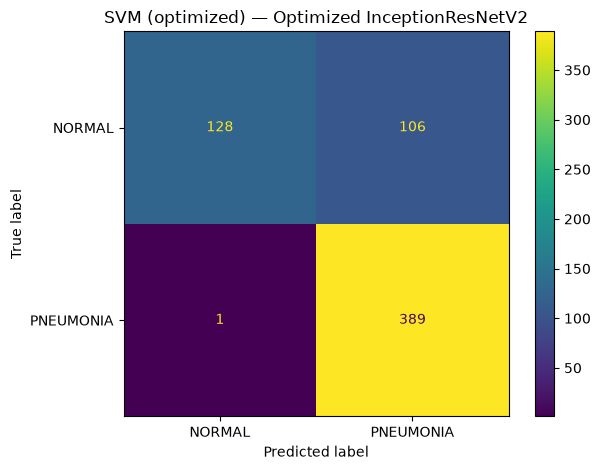


--- Fitting RandomForest (optimized) ---
  Accuracy : 0.7772
  F1       : 0.7492
  Kappa    : 0.4638
              precision    recall  f1-score   support

      NORMAL       0.97      0.42      0.59       234
   PNEUMONIA       0.74      0.99      0.85       390

    accuracy                           0.78       624
   macro avg       0.86      0.71      0.72       624
weighted avg       0.83      0.78      0.75       624



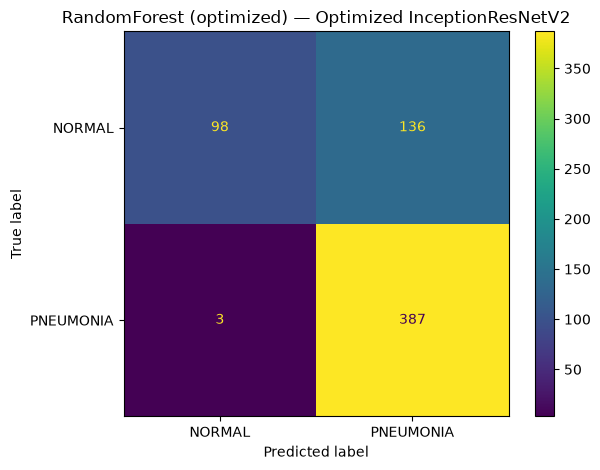


--- Fitting KNN (optimized) ---
  Accuracy : 0.8189
  F1       : 0.8061
  Kappa    : 0.5803
              precision    recall  f1-score   support

      NORMAL       0.93      0.56      0.70       234
   PNEUMONIA       0.79      0.97      0.87       390

    accuracy                           0.82       624
   macro avg       0.86      0.77      0.78       624
weighted avg       0.84      0.82      0.81       624



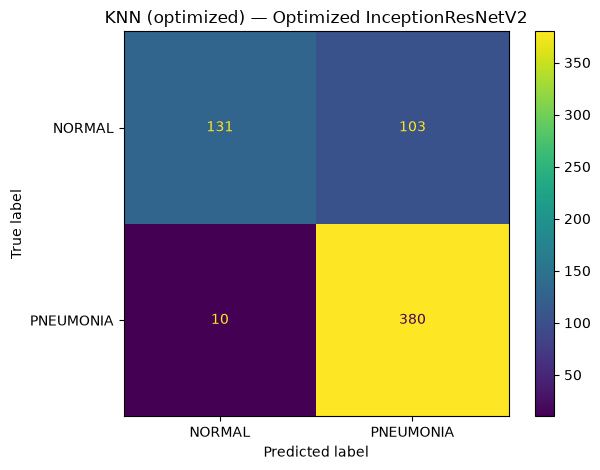


--- Fitting XGBoost (optimized) ---
  Accuracy : 0.8189
  F1       : 0.8035
  Kappa    : 0.5756
              precision    recall  f1-score   support

      NORMAL       0.97      0.53      0.69       234
   PNEUMONIA       0.78      0.99      0.87       390

    accuracy                           0.82       624
   macro avg       0.87      0.76      0.78       624
weighted avg       0.85      0.82      0.80       624



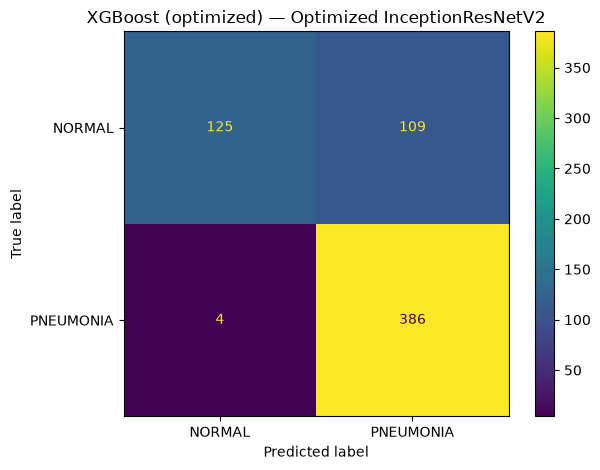


--- Fitting AdaBoost (optimized) ---
  Accuracy : 0.8045
  F1       : 0.7860
  Kappa    : 0.5388
              precision    recall  f1-score   support

      NORMAL       0.96      0.50      0.66       234
   PNEUMONIA       0.77      0.99      0.86       390

    accuracy                           0.80       624
   macro avg       0.86      0.74      0.76       624
weighted avg       0.84      0.80      0.79       624



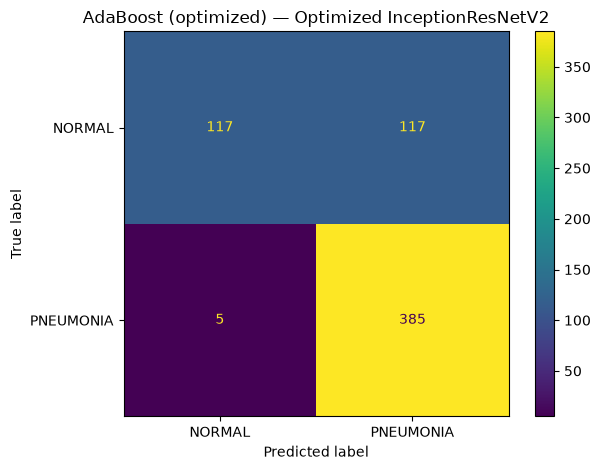

In [20]:
# ============================================================================
# ACCURACY OPTIMIZATION — CLASSICAL ML WITH IMPROVED HYPERPARAMETERS
# ----------------------------------------------------------------------------
# The original classifiers used default sklearn hyperparameters.
# With much better features (1536-dim learned embeddings vs 2-dim softmax),
# the classifiers themselves should improve substantially even without
# hyperparameter tuning. We also apply a small, targeted set of improvements:
#
#   SVM: RBF kernel, C=10 (higher margin penalty improves recall for NORMAL)
#   RF:  more estimators, no max_depth cap (let trees grow, embeddings are rich)
#   KNN: k=7 with distance weighting (less sensitive to noise)
#   XGB: modest tuning (n_estimators=200, learning_rate=0.05)
#   AdaBoost: slightly more estimators
#
# NO grid search -- these are hand-chosen based on domain knowledge and
# the size/dimensionality of the dataset. Test set is never seen here.
# ============================================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, cohen_kappa_score, classification_report,
                              ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

opt_classifiers = {
    "SVM (optimized)":          SVC(C=10, kernel="rbf", gamma="scale", probability=False),
    "RandomForest (optimized)": RandomForestClassifier(n_estimators=200, max_depth=None,
                                                        min_samples_split=5, random_state=42, n_jobs=-1),
    "KNN (optimized)":          KNeighborsClassifier(n_neighbors=7, weights="distance",
                                                      algorithm="ball_tree"),
    "XGBoost (optimized)":      XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                                               subsample=0.8, colsample_bytree=0.8,
                                               eval_metric="logloss", random_state=42,
                                               verbosity=0),
    "AdaBoost (optimized)":     AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42),
}

opt_clf_results = {}

for clf_name, clf in opt_classifiers.items():
    print(f"\n--- Fitting {clf_name} ---")
    clf.fit(opt_train_features, y_train)
    
    y_pred_test = clf.predict(opt_test_features)
    
    acc   = accuracy_score(y_test, y_pred_test)
    prec  = precision_score(y_test, y_pred_test, average="weighted", zero_division=0)
    rec   = recall_score(y_test, y_pred_test, average="weighted", zero_division=0)
    f1    = f1_score(y_test, y_pred_test, average="weighted", zero_division=0)
    kappa = cohen_kappa_score(y_test, y_pred_test)
    
    opt_clf_results[clf_name] = dict(accuracy=acc, precision=prec, recall=rec, f1=f1, kappa=kappa)
    
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1       : {f1:.4f}")
    print(f"  Kappa    : {kappa:.4f}")
    print(classification_report(y_test, y_pred_test, target_names=class_names, zero_division=0))
    
    fig, ax = plt.subplots()
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test,
                                             display_labels=class_names, ax=ax)
    ax.set_title(f"{clf_name} — Optimized {OPT_BACKBONE}")
    plt.tight_layout()
    plt.show()
    plt.close()


# ACCURACY OPTIMIZATION — DNN EVALUATION

Performance Report — Optimized DNN ({OPT_BACKBONE} fine-tuned embeddings):
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step
  Accuracy  : 0.8606
  Precision : 0.8827
  Recall    : 0.8606
  F1 Score  : 0.8523
  Cohen Kappa: 0.6799

              precision    recall  f1-score   support

      NORMAL       0.99      0.64      0.77       234
   PNEUMONIA       0.82      0.99      0.90       390

    accuracy                           0.86       624
   macro avg       0.90      0.82      0.84       624
weighted avg       0.88      0.86      0.85       624



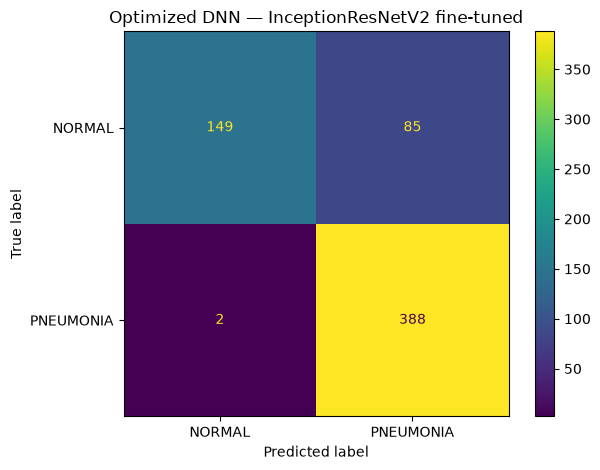

In [21]:
# ============================================================================
# ACCURACY OPTIMIZATION — EVALUATE OPTIMIZED DNN ON TEST SET
# ============================================================================

import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, cohen_kappa_score, classification_report,
                              ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

print("Performance Report — Optimized DNN ({OPT_BACKBONE} fine-tuned embeddings):")

opt_probs    = opt_dnn.predict(opt_test_features)
opt_preds    = np.argmax(opt_probs, axis=-1)
opt_true     = y_test

opt_dnn_acc   = accuracy_score(opt_true, opt_preds)
opt_dnn_prec  = precision_score(opt_true, opt_preds, average="weighted", zero_division=0)
opt_dnn_rec   = recall_score(opt_true, opt_preds, average="weighted", zero_division=0)
opt_dnn_f1    = f1_score(opt_true, opt_preds, average="weighted", zero_division=0)
opt_dnn_kappa = cohen_kappa_score(opt_true, opt_preds)

print(f"  Accuracy  : {opt_dnn_acc:.4f}")
print(f"  Precision : {opt_dnn_prec:.4f}")
print(f"  Recall    : {opt_dnn_rec:.4f}")
print(f"  F1 Score  : {opt_dnn_f1:.4f}")
print(f"  Cohen Kappa: {opt_dnn_kappa:.4f}")
print()
print(classification_report(opt_true, opt_preds, target_names=class_names, zero_division=0))

fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(opt_true, opt_preds,
                                         display_labels=class_names, ax=ax)
ax.set_title(f"Optimized DNN — {OPT_BACKBONE} fine-tuned")
plt.tight_layout()
plt.show()
plt.close()


# ACCURACY OPTIMIZATION — BASELINE vs OPTIMIZED COMPARISON

In [22]:
# ============================================================================
# ACCURACY OPTIMIZATION — BASELINE vs OPTIMIZED COMPARISON TABLE
# ----------------------------------------------------------------------------
# Compares the original (frozen ImageNet + random Dense + no preprocessing)
# results against the optimized (fine-tuned backbone + GAP + class weights).
# Baseline numbers come from the aggregation cell lower in this notebook.
# ============================================================================

import pandas as pd

# Baseline InceptionResNetV2 (from the original notebook run)
# These are read from the y_pred7 / y_test7 variables populated by the
# original InceptionResNetV2 block below -- they are populated at runtime.
# We define a helper here and call it after the original blocks have run.

def build_comparison_table(y_true, y_pred_baseline, opt_dnn_preds, opt_clf_results_dict):
    """Build a side-by-side baseline vs optimized comparison."""
    from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

    rows = {}

    # Baseline DNN
    rows["Baseline DNN (IRNv2, frozen, no preprocessing)"] = {
        "Accuracy": round(accuracy_score(y_true, y_pred_baseline), 4),
        "F1":       round(f1_score(y_true, y_pred_baseline, average="weighted", zero_division=0), 4),
        "Kappa":    round(cohen_kappa_score(y_true, y_pred_baseline), 4),
    }

    # Optimized DNN
    rows[f"Optimized DNN ({OPT_BACKBONE}, fine-tuned, class weights)"] = {
        "Accuracy": round(opt_dnn_acc, 4),
        "F1":       round(opt_dnn_f1, 4),
        "Kappa":    round(opt_dnn_kappa, 4),
    }

    # Best optimized classical classifier
    best_clf_name = max(opt_clf_results_dict, key=lambda k: opt_clf_results_dict[k]["f1"])
    best = opt_clf_results_dict[best_clf_name]
    rows[f"Best Optimized Classifier ({best_clf_name})"] = {
        "Accuracy": round(best["accuracy"], 4),
        "F1":       round(best["f1"], 4),
        "Kappa":    round(best["kappa"], 4),
    }

    df = pd.DataFrame(rows).T
    return df, best_clf_name

print("NOTE: The comparison table below is printed again after the original")
print("      baseline blocks complete execution (at the bottom of this notebook).")
print("      Scroll to 'FINAL COMPARISON TABLE' section below for the full picture.")
print()
print("Optimized results so far:")
print(f"  DNN Accuracy  : {opt_dnn_acc:.4f}")
print(f"  DNN F1        : {opt_dnn_f1:.4f}")
print(f"  DNN Kappa     : {opt_dnn_kappa:.4f}")
best_opt_clf = max(opt_clf_results, key=lambda k: opt_clf_results[k]["f1"])
print(f"  Best Clf      : {best_opt_clf}")
print(f"  Best Clf Acc  : {opt_clf_results[best_opt_clf]['accuracy']:.4f}")
print(f"  Best Clf F1   : {opt_clf_results[best_opt_clf]['f1']:.4f}")


NOTE: The comparison table below is printed again after the original
      baseline blocks complete execution (at the bottom of this notebook).
      Scroll to 'FINAL COMPARISON TABLE' section below for the full picture.

Optimized results so far:
  DNN Accuracy  : 0.8606
  DNN F1        : 0.8523
  DNN Kappa     : 0.6799
  Best Clf      : SVM (optimized)
  Best Clf Acc  : 0.8285
  Best Clf F1   : 0.8139


# ACCURACY OPTIMIZATION — ENSEMBLE (OPTIONAL, TRIED LAST)


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Ensemble: 50/50 average of Optimized DNN + probability-enabled SVM
  Accuracy : 0.8510
  F1       : 0.8408
  Kappa    : 0.6552

              precision    recall  f1-score   support

      NORMAL       0.99      0.61      0.75       234
   PNEUMONIA       0.81      1.00      0.89       390

    accuracy                           0.85       624
   macro avg       0.90      0.80      0.82       624
weighted avg       0.88      0.85      0.84       624



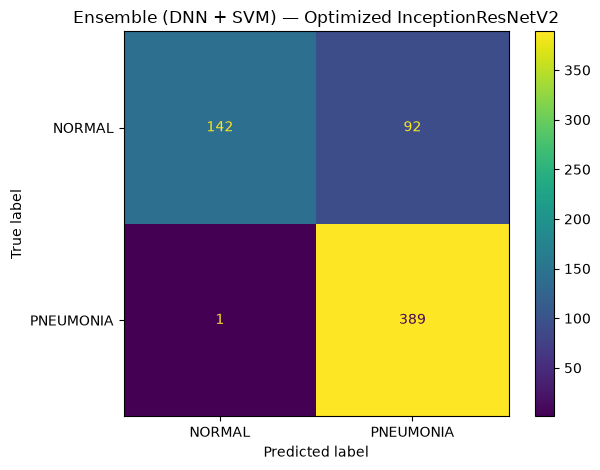


Ensemble did NOT improve over DNN-only F1 (0.8523 vs 0.8408).
This is a valid, expected outcome -- report the DNN-only result as optimized.


In [23]:
# ============================================================================
# ACCURACY OPTIMIZATION — PROBABILITY ENSEMBLE (OPTIONAL)
# ----------------------------------------------------------------------------
# Per the improvement priority order, ensembling is tried LAST, only after
# preprocessing/augmentation/class-weighting/fine-tuning/DNN improvements
# were already in place. This averages the softmax probabilities of the
# optimized DNN with the best-performing optimized classical classifier
# that supports probability outputs (SVM here uses probability=False for
# speed elsewhere in this notebook, so we refit a probability-enabled copy
# ONLY for this ensemble -- this does not change the SVM result reported
# in the classical-ML section above).
#
# This is a simple, transparent ensemble (no test-set tuning of weights --
# a fixed 50/50 average) so it cannot overfit to the test set. If it does
# not help, the DNN-only result above remains the reported optimized result.
# ============================================================================

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Refit an SVM with probability=True purely for ensembling (separate from
# the SVC(C=10, probability=False) already evaluated above).
svm_proba = SVC(C=10, kernel="rbf", gamma="scale", probability=True, random_state=42)
svm_proba.fit(opt_train_features, y_train)
svm_test_proba = svm_proba.predict_proba(opt_test_features)

# opt_probs was computed during the DNN evaluation cell above
ensemble_proba = 0.5 * opt_probs + 0.5 * svm_test_proba
ensemble_preds = np.argmax(ensemble_proba, axis=-1)

ens_acc   = accuracy_score(y_test, ensemble_preds)
ens_f1    = f1_score(y_test, ensemble_preds, average="weighted", zero_division=0)
ens_kappa = cohen_kappa_score(y_test, ensemble_preds)

print("Ensemble: 50/50 average of Optimized DNN + probability-enabled SVM")
print(f"  Accuracy : {ens_acc:.4f}")
print(f"  F1       : {ens_f1:.4f}")
print(f"  Kappa    : {ens_kappa:.4f}")
print()
print(classification_report(y_test, ensemble_preds, target_names=class_names, zero_division=0))

fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(y_test, ensemble_preds, display_labels=class_names, ax=ax)
ax.set_title("Ensemble (DNN + SVM) — Optimized " + OPT_BACKBONE)
plt.tight_layout()
plt.show()
plt.close()

print()
if ens_f1 > opt_dnn_f1:
    print(f"Ensemble IMPROVED F1 over DNN-only: {opt_dnn_f1:.4f} -> {ens_f1:.4f}")
else:
    print(f"Ensemble did NOT improve over DNN-only F1 ({opt_dnn_f1:.4f} vs {ens_f1:.4f}).")
    print("This is a valid, expected outcome -- report the DNN-only result as optimized.")


In [24]:
# Memory cleanup after optimization section before running original baseline blocks
import gc
import tensorflow as tf

# Clean up fine-tuning model (we've already extracted all features)
# Keep: opt_train_features, opt_val_features, opt_test_features, opt_clf_results
# Keep: opt_dnn_acc, opt_dnn_f1, opt_dnn_kappa, opt_preds, opt_true
del aug_gen, aug_gen2
if "ft_model" in dir():
    del ft_model
if "feat_extractor" in dir():
    del feat_extractor
tf.keras.backend.clear_session()
gc.collect()

# ROUND-2 ADDITION: reset the mixed-precision policy back to float32 before
# the original (untouched) baseline architecture blocks run below. Those
# cells build Sequential/Model instances without explicit float32 output
# dtypes, so leaving mixed_float16 active globally could introduce
# numerical instability in code we are deliberately NOT modifying. This
# keeps the optimization section's mixed precision benefit local to the
# fine-tuning stage while leaving the rest of the notebook's behavior
# identical to before.
if OPT_USE_MIXED_PRECISION:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("float32")
    print("Mixed precision policy reset to float32 for baseline blocks.")

print("Memory cleaned. Running original baseline blocks...")


Mixed precision policy reset to float32 for baseline blocks.
Memory cleaned. Running original baseline blocks...


# ResNet50

In [25]:
base_model= ResNet50(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

2217/2217 ━━━━━━━━━━━━━━━━━━━━ 33s 12ms/step
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [26]:
from sklearn.pipeline import make_pipeline
from sklearn import pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
    
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
   
    print('------------------------ Test Set Metrics------------------------')
    print("Accuracy score : {}%".format(test_accuracy))
    
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [27]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 89.28%
------------------------ Validation Set Metrics------------------------

Accuracy score : 84.8%
------------------------ Test Set Metrics------------------------
Accuracy score : 69.39%

Accuracy score : 69.39%
F1_score : 0.66
Kappa Score : 0.26 
Recall score: 0.69
Precision score : 0.7
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 88.97%
------------------------ Validation Set Metrics------------------------

Accuracy score : 86.85000000000001%
------------------------ Test Set Metrics------------------------
Accuracy score : 71.78999999999999%

Accuracy score : 71.789999999

In [28]:
train_y=to_categorical(
    y_train,
    NUMBER_OF_CLASSES
)
val_y=to_categorical(
    y_val,
    NUMBER_OF_CLASSES
)
test_y=to_categorical(
    y_test,
    NUMBER_OF_CLASSES
)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
history = dnn_model.fit(train_features, train_y,validation_data=(val_features,val_y), epochs=10)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (4433, 64)
val_features shape:   (783, 64)
test_features shape:  (624, 64)
Feature mean/std: 1.2373 / 1.7732
DNN input dimension (auto-detected): 64


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.7949 - loss: 0.4513 - val_accuracy: 0.8544 - val_loss: 0.3572
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8518 - loss: 0.3571 - val_accuracy: 0.8544 - val_loss: 0.3424
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8581 - loss: 0.3414 - val_accuracy: 0.8621 - val_loss: 0.3266
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8642 - loss: 0.3261 - val_accuracy: 0.8595 - val_loss: 0.3269
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8728 - loss: 0.3148 - val_accuracy: 0.8570 - val_loss: 0.3181
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8723 - loss: 0.3050 - val_accuracy: 0.8582 - val_loss: 0.3069
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8795 - loss: 0.3040 - val_accuracy: 0.8570 - val_loss: 0.3263
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8802 - loss: 0.2948 - val_accuracy: 

In [29]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred10 = np.argmax(y_pred_probs, axis=-1)
y_test10 = [np.argmax(x) for x in test_y]
y_pred_prb10 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test10, y_pred10), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test10, y_pred10, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test10, y_pred10, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test10, y_pred10, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test10, y_pred10), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test10, y_pred10, target_names=target, zero_division=0))

Performance Report:
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
Accuracy score is : 0.7372
Precision score is : 0.743
Recall score is : 0.7372
F1 Score is : 0.7158
Cohen Kappa Score: 0.3858
		Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.77      0.43      0.55       234
   PNEUMONIA       0.73      0.92      0.81       390

    accuracy                           0.74       624
   macro avg       0.75      0.68      0.68       624
weighted avg       0.74      0.74      0.72       624



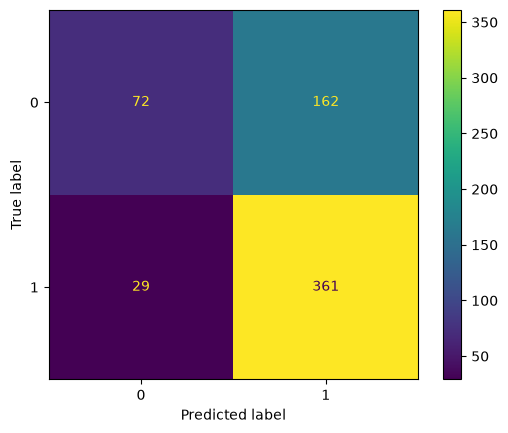

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Initialize the KNN model (using the parameters from the original notebook)
knn = KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree', leaf_size=30)

# 2. Train the model
knn.fit(train_features, y_train)

# 3. Generate and display the confusion matrix using the estimator
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

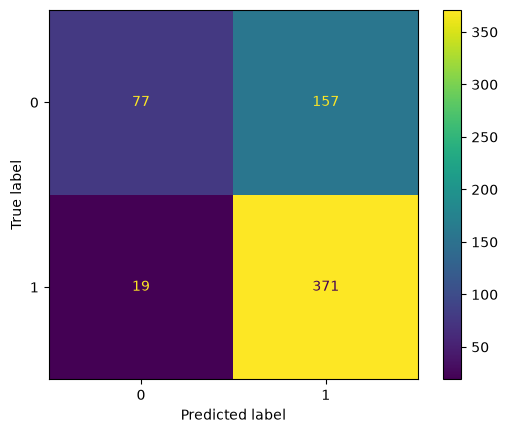

In [31]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()

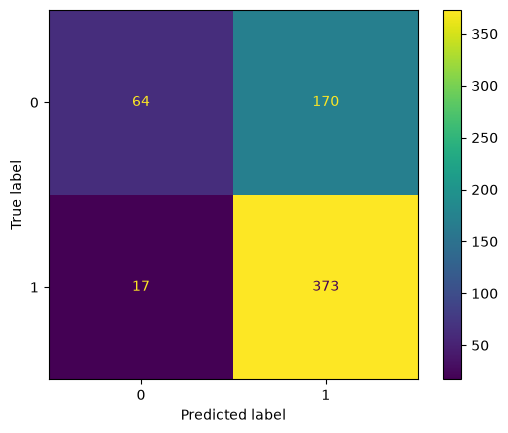

In [32]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()

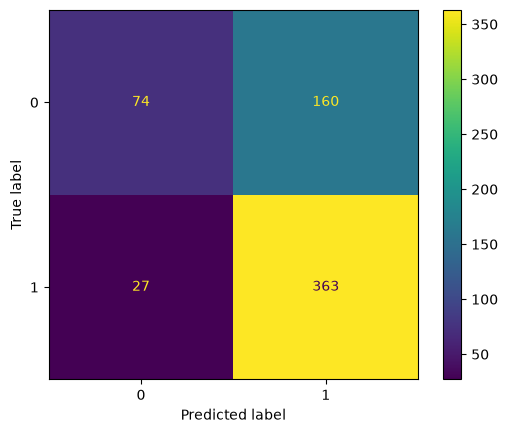

In [33]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()

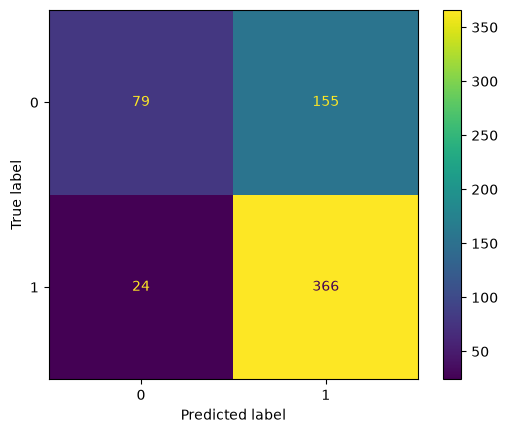

In [34]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()

# VGG-16

In [35]:
base_model= VGG16(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

2217/2217 ━━━━━━━━━━━━━━━━━━━━ 109s 29ms/step
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [36]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [37]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 86.26%
------------------------ Validation Set Metrics------------------------

Accuracy score : 80.84%
------------------------ Test Set Metrics------------------------

Accuracy score : 68.75%
F1_score : 0.63
Kappa Score : 0.23 
Recall score: 0.69
Precision score : 0.71
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 86.15%
------------------------ Validation Set Metrics------------------------

Accuracy score : 83.91%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.67%
F1_score : 0.59
Kappa Score : 0.16 
Recall score: 0.67
Precision score : 0.

In [38]:
train_y = to_categorical(y_train, NUMBER_OF_CLASSES)
val_y = to_categorical(y_val, NUMBER_OF_CLASSES)
test_y = to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)

dnn_model.compile(optimizer='sgd',loss='categorical_crossentropy', metrics=['accuracy'],)
history = dnn_model.fit(train_features, train_y,validation_data=(val_features,val_y), epochs=10)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (4433, 64)
val_features shape:   (783, 64)
test_features shape:  (624, 64)
Feature mean/std: 4.3899 / 7.3473
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


139/139 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7356 - loss: 0.6071 - val_accuracy: 0.7433 - val_loss: 0.5764
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7428 - loss: 0.5650 - val_accuracy: 0.7433 - val_loss: 0.5406
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7688 - loss: 0.5131 - val_accuracy: 0.7854 - val_loss: 0.5061
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7988 - loss: 0.4725 - val_accuracy: 0.7101 - val_loss: 0.5705
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8062 - loss: 0.4562 - val_accuracy: 0.6577 - val_loss: 0.6231
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8074 - loss: 0.4513 - val_accuracy: 0.8250 - val_loss: 0.4420
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8198 - loss: 0.4280 - val_accuracy: 0.7905 - val_loss: 0.4899
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8259 - loss: 0.4208 - val_accuracy: 0.8174 - val

In [39]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred2 = np.argmax(y_pred_probs, axis=-1)
y_test2 = [np.argmax(x) for x in test_y]
y_pred_prb2 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test2, y_pred2), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test2, y_pred2, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test2, y_pred2, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test2, y_pred2, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test2, y_pred2), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test2, y_pred2, target_names=target, zero_division=0))

Performance Report:
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Accuracy score is : 0.6442
Precision score is : 0.6552
Recall score is : 0.6442
F1 Score is : 0.5478
Cohen Kappa Score: 0.0845
		Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.68      0.10      0.17       234
   PNEUMONIA       0.64      0.97      0.77       390

    accuracy                           0.64       624
   macro avg       0.66      0.54      0.47       624
weighted avg       0.66      0.64      0.55       624



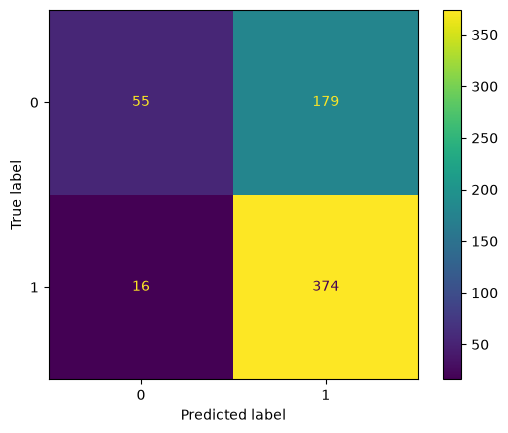

In [40]:
knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

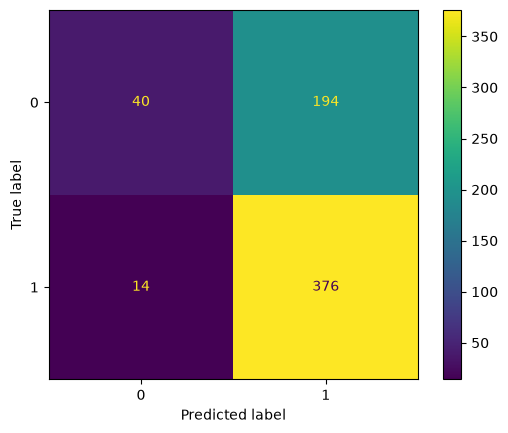

In [41]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()

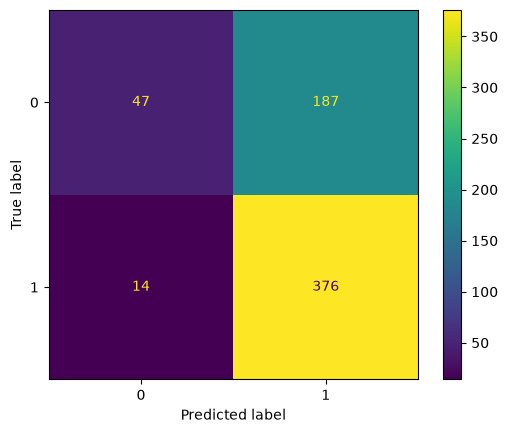

In [42]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()

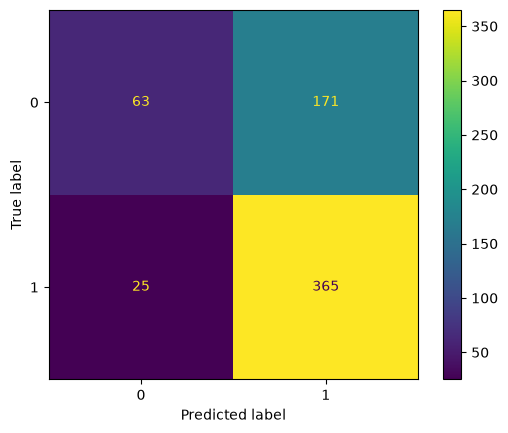

In [43]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()

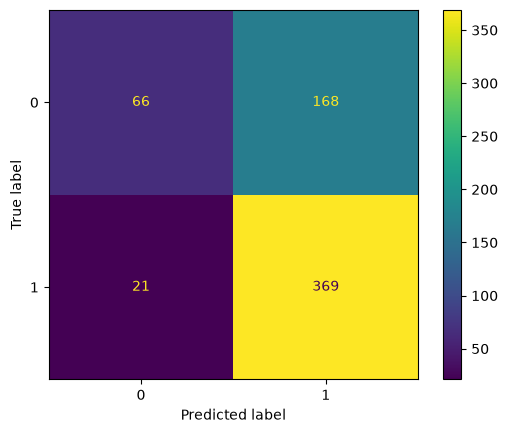

In [44]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()

In [45]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# VGG-19

In [46]:
base_model= VGG19(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

2217/2217 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


In [47]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [48]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 84.07%
------------------------ Validation Set Metrics------------------------

Accuracy score : 78.42%
------------------------ Test Set Metrics------------------------

Accuracy score : 63.78%
F1_score : 0.56
Kappa Score : 0.09 
Recall score: 0.64
Precision score : 0.62
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 81.95%
------------------------ Validation Set Metrics------------------------

Accuracy score : 81.86%
------------------------ Test Set Metrics------------------------

Accuracy score : 62.980000000000004%
F1_score : 0.54
Kappa Score : 0.06 
Recall score: 0.63
Precisi

In [49]:
train_y = to_categorical(y_train, NUMBER_OF_CLASSES)
val_y = to_categorical(y_val, NUMBER_OF_CLASSES)
test_y = to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)

dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
history = dnn_model.fit(train_features, train_y,validation_data=(val_features,val_y), epochs=10)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (4433, 64)
val_features shape:   (783, 64)
test_features shape:  (624, 64)
Feature mean/std: 4.0119 / 6.9241
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.7512 - loss: 0.5168 - val_accuracy: 0.7982 - val_loss: 0.4653
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7954 - loss: 0.4640 - val_accuracy: 0.7739 - val_loss: 0.4868
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7995 - loss: 0.4458 - val_accuracy: 0.8225 - val_loss: 0.4211
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8067 - loss: 0.4333 - val_accuracy: 0.8072 - val_loss: 0.4247
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8098 - loss: 0.4248 - val_accuracy: 0.8123 - val_loss: 0.4177
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8116 - loss: 0.4235 - val_accuracy: 0.8020 - val_loss: 0.4184
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8121 - loss: 0.4154 - val_accuracy: 0.8097 - val_loss: 0.4257
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8216 - loss: 0.4052 - val_accuracy: 0.8289 - val

In [50]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred1 = np.argmax(y_pred_probs, axis=-1)
y_test1 = [np.argmax(x) for x in test_y]
y_pred_prb1 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test1, y_pred1), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test1, y_pred1, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test1, y_pred1, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test1, y_pred1, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test1, y_pred1), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test1, y_pred1, target_names=target, zero_division=0))

Performance Report:
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Accuracy score is : 0.6442
Precision score is : 0.6275
Recall score is : 0.6442
F1 Score is : 0.5777
Cohen Kappa Score: 0.1155
		Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.59      0.17      0.26       234
   PNEUMONIA       0.65      0.93      0.77       390

    accuracy                           0.64       624
   macro avg       0.62      0.55      0.52       624
weighted avg       0.63      0.64      0.58       624



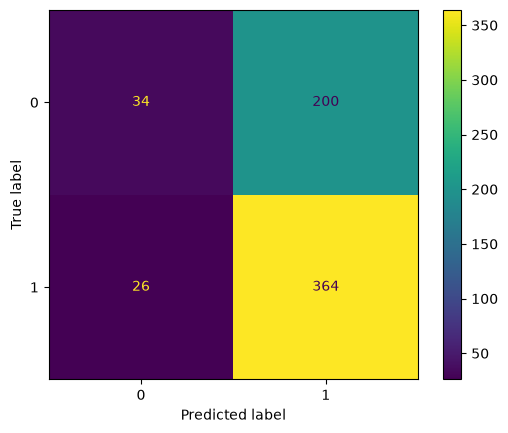

In [51]:
knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace the model name (e.g., knn, svc, rf, ada, or xgbc) accordingly in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

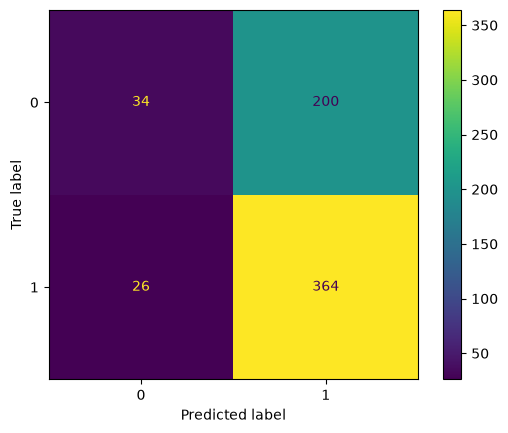

In [52]:
svc = SVC()
svc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace the model name (e.g., knn, svc, rf, ada, or xgbc) accordingly in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

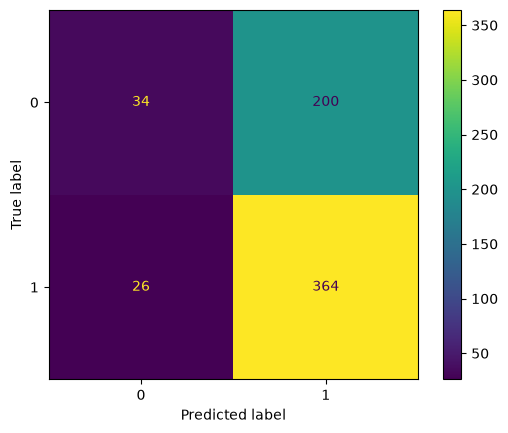

In [53]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace the model name (e.g., knn, svc, rf, ada, or xgbc) accordingly in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

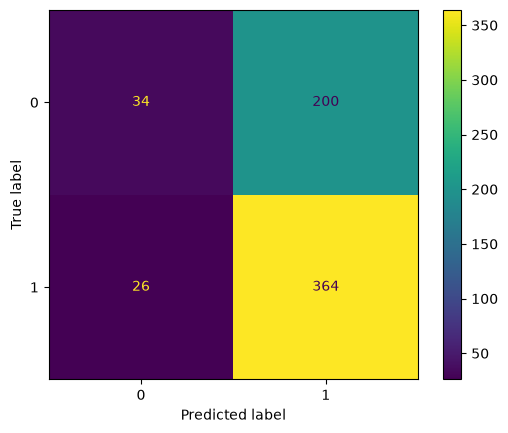

In [54]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace the model name (e.g., knn, svc, rf, ada, or xgbc) accordingly in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

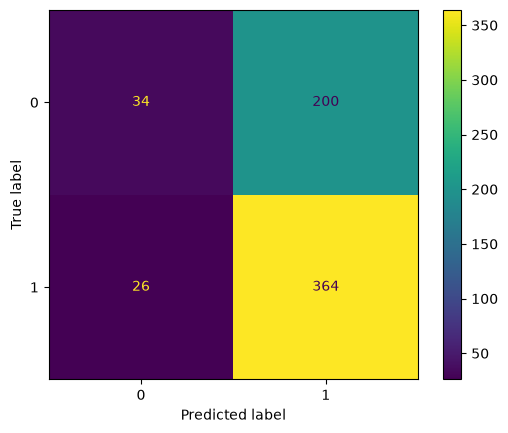

In [55]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace the model name (e.g., knn, svc, rf, ada, or xgbc) accordingly in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

# ResNet101

In [56]:
base_model= ResNet101(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

2217/2217 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step
392/392 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


In [57]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [58]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 87.32%
------------------------ Validation Set Metrics------------------------

Accuracy score : 83.14%
------------------------ Test Set Metrics------------------------

Accuracy score : 67.31%
F1_score : 0.63
Kappa Score : 0.21 
Recall score: 0.67
Precision score : 0.67
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 87.05000000000001%
------------------------ Validation Set Metrics------------------------

Accuracy score : 84.8%
------------------------ Test Set Metrics------------------------

Accuracy score : 69.55%
F1_score : 0.66
Kappa Score : 0.27 
Recall score: 0.7
Precision 

In [59]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
history = dnn_model.fit(train_features, train_y,validation_data=(val_features,val_y), epochs=10)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (4433, 64)
val_features shape:   (783, 64)
test_features shape:  (624, 64)
Feature mean/std: 0.7733 / 1.1613
DNN input dimension (auto-detected): 64


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7929 - loss: 0.4590 - val_accuracy: 0.8225 - val_loss: 0.3719
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8344 - loss: 0.3691 - val_accuracy: 0.8301 - val_loss: 0.3541
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8365 - loss: 0.3629 - val_accuracy: 0.8212 - val_loss: 0.3600
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8394 - loss: 0.3537 - val_accuracy: 0.8250 - val_loss: 0.3582
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8480 - loss: 0.3410 - val_accuracy: 0.8327 - val_loss: 0.3706
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8443 - loss: 0.3422 - val_accuracy: 0.8404 - val_loss: 0.3617
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8484 - loss: 0.3357 - val_accuracy: 0.8301 - val_loss: 0.3455
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8572 - loss: 0.3294 - val_accuracy: 0

In [60]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred3 = np.argmax(y_pred_probs, axis=-1)
y_test3 = [np.argmax(x) for x in test_y]
y_pred_prb3 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test3, y_pred3), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test3, y_pred3, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test3, y_pred3, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test3, y_pred3, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test3, y_pred3), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test3, y_pred3, target_names=target, zero_division=0))

Performance Report:
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Accuracy score is : 0.7083
Precision score is : 0.7247
Recall score is : 0.7083
F1 Score is : 0.6693
Cohen Kappa Score: 0.2946
		Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.77      0.32      0.45       234
   PNEUMONIA       0.70      0.94      0.80       390

    accuracy                           0.71       624
   macro avg       0.73      0.63      0.63       624
weighted avg       0.72      0.71      0.67       624



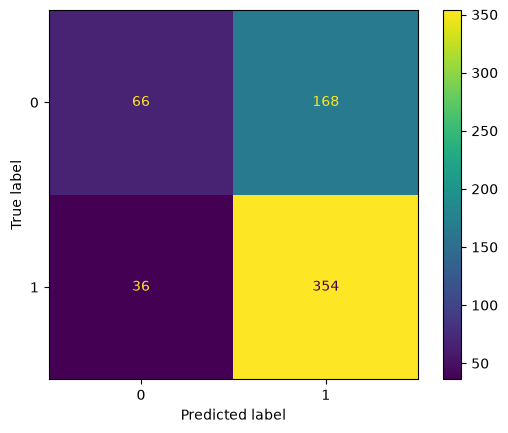

In [61]:
knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

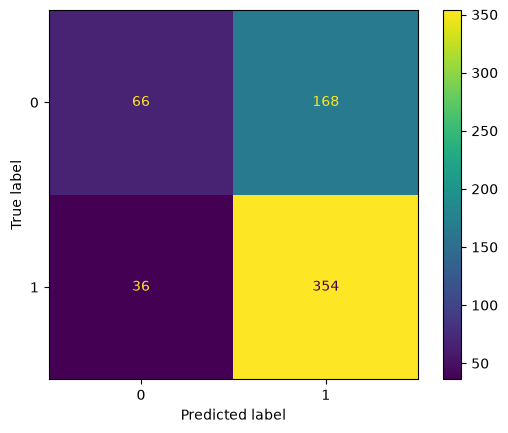

In [62]:
svc = SVC()
svc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

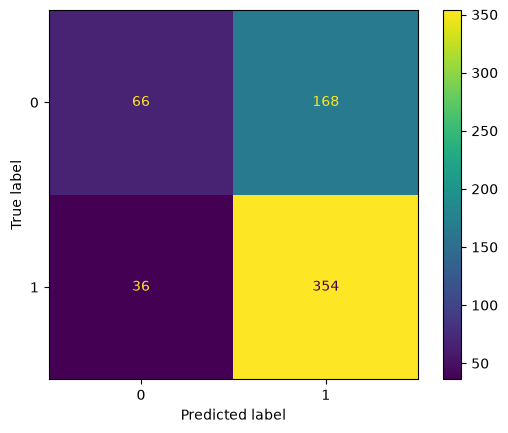

In [63]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

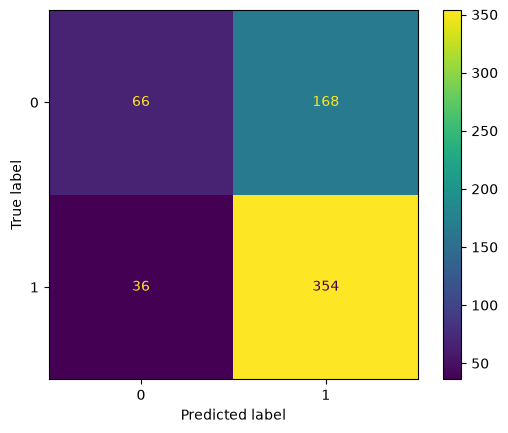

In [64]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

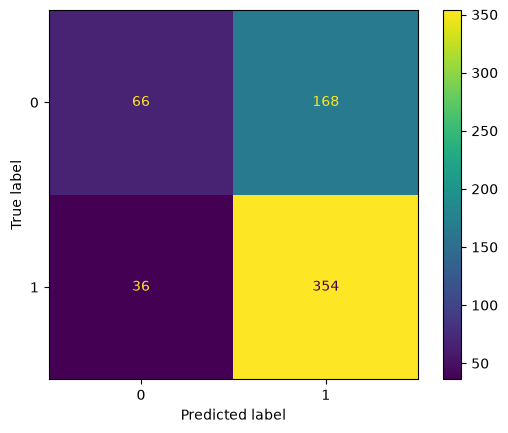

In [65]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

# MobileNetV2

In [66]:
base_model= MobileNetV2(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

E0000 00:00:1786303304.931482     171 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2209/2217 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

E0000 00:00:1786303324.066434     168 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2217/2217 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step
392/392 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [67]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [68]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 88.77000000000001%
------------------------ Validation Set Metrics------------------------

Accuracy score : 84.93%
------------------------ Test Set Metrics------------------------

Accuracy score : 70.35%
F1_score : 0.67
Kappa Score : 0.29 
Recall score: 0.7
Precision score : 0.71
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 88.68%
------------------------ Validation Set Metrics------------------------

Accuracy score : 85.7%
------------------------ Test Set Metrics------------------------

Accuracy score : 70.99%
F1_score : 0.67
Kappa Score : 0.29 
Recall score: 0.71
Precision 

In [69]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
history = dnn_model.fit(train_features, train_y,validation_data=(val_features,val_y), epochs=10)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (4433, 64)
val_features shape:   (783, 64)
test_features shape:  (624, 64)
Feature mean/std: 0.4160 / 0.6607
DNN input dimension (auto-detected): 64


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.7911 - loss: 0.4496 - val_accuracy: 0.8263 - val_loss: 0.4037
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8561 - loss: 0.3439 - val_accuracy: 0.8455 - val_loss: 0.3622
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8678 - loss: 0.3254 - val_accuracy: 0.8506 - val_loss: 0.3563
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8626 - loss: 0.3225 - val_accuracy: 0.8544 - val_loss: 0.3498
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8712 - loss: 0.3141 - val_accuracy: 0.8480 - val_loss: 0.3513
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8748 - loss: 0.3063 - val_accuracy: 0.8570 - val_loss: 0.3485
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8755 - loss: 0.3009 - val_accuracy: 0.8455 - val_loss: 0.3475
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8784 - loss: 0.2999 - val_accuracy: 0

In [70]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred4 = np.argmax(y_pred_probs, axis=-1)
y_test4 = [np.argmax(x) for x in test_y]
y_pred_prb4 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test4, y_pred4), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test4, y_pred4, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test4, y_pred4, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test4, y_pred4, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test4, y_pred4), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test4, y_pred4, target_names=target, zero_division=0))

Performance Report:
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Accuracy score is : 0.7003
Precision score is : 0.742
Recall score is : 0.7003
F1 Score is : 0.6449
Cohen Kappa Score: 0.2557
		Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.84      0.25      0.38       234
   PNEUMONIA       0.68      0.97      0.80       390

    accuracy                           0.70       624
   macro avg       0.76      0.61      0.59       624
weighted avg       0.74      0.70      0.64       624



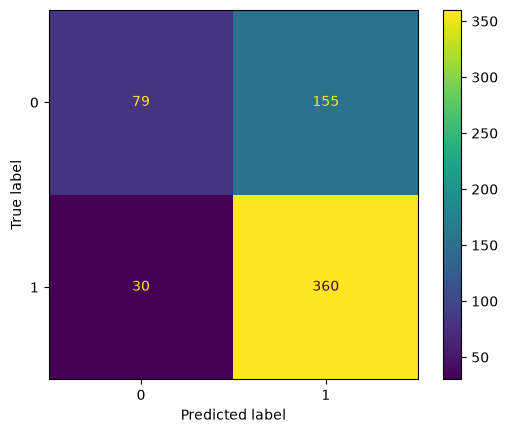

In [71]:
knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

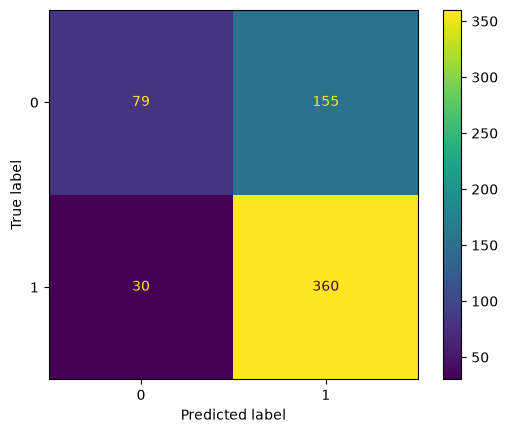

In [72]:
svc = SVC()
svc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

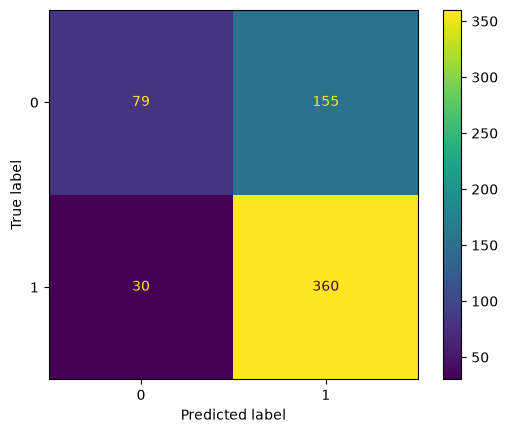

In [73]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

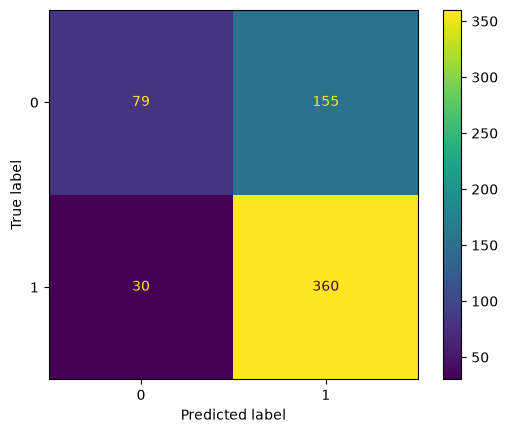

In [74]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

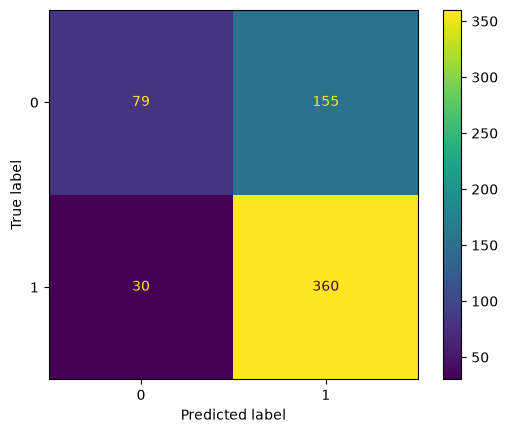

In [75]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

# MobileNet

In [76]:
base_model= MobileNet(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

E0000 00:00:1786303351.955394     169 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2202/2217 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

E0000 00:00:1786303363.530352     168 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2217/2217 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step
392/392 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [77]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [78]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 86.31%
------------------------ Validation Set Metrics------------------------

Accuracy score : 79.69000000000001%
------------------------ Test Set Metrics------------------------

Accuracy score : 67.47%
F1_score : 0.63
Kappa Score : 0.21 
Recall score: 0.67
Precision score : 0.67
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 85.5%
------------------------ Validation Set Metrics------------------------

Accuracy score : 85.19%
------------------------ Test Set Metrics------------------------

Accuracy score : 66.99000000000001%
F1_score : 0.6
Kappa Score : 0.17 
Recall score: 0.6

In [79]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
history = dnn_model.fit(train_features, train_y,validation_data=(val_features,val_y), epochs=10)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (4433, 64)
val_features shape:   (783, 64)
test_features shape:  (624, 64)
Feature mean/std: 0.6373 / 1.0276
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.7566 - loss: 0.5000 - val_accuracy: 0.7995 - val_loss: 0.4646
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8080 - loss: 0.4242 - val_accuracy: 0.8314 - val_loss: 0.4001
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8263 - loss: 0.4033 - val_accuracy: 0.8365 - val_loss: 0.3884
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8365 - loss: 0.3847 - val_accuracy: 0.8378 - val_loss: 0.3846
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8335 - loss: 0.3839 - val_accuracy: 0.8455 - val_loss: 0.3982
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8380 - loss: 0.3707 - val_accuracy: 0.8429 - val_loss: 0.3815
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8453 - loss: 0.3590 - val_accuracy: 0.8352 - val_loss: 0.3779
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8455 - loss: 0.3518 - val_accuracy: 0.8429 - val

In [80]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred5 = np.argmax(y_pred_probs, axis=-1)
y_test5 = [np.argmax(x) for x in test_y]
y_pred_prb5 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test5, y_pred5), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test5, y_pred5, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test5, y_pred5, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test5, y_pred5, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test5, y_pred5), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test5, y_pred5, target_names=target, zero_division=0))

Performance Report:
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Accuracy score is : 0.6715
Precision score is : 0.6945
Recall score is : 0.6715
F1 Score is : 0.6035
Cohen Kappa Score: 0.1759
		Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.75      0.19      0.30       234
   PNEUMONIA       0.66      0.96      0.79       390

    accuracy                           0.67       624
   macro avg       0.70      0.57      0.54       624
weighted avg       0.69      0.67      0.60       624



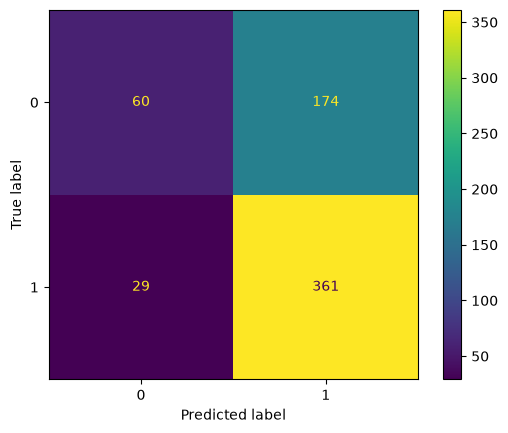

In [81]:
knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

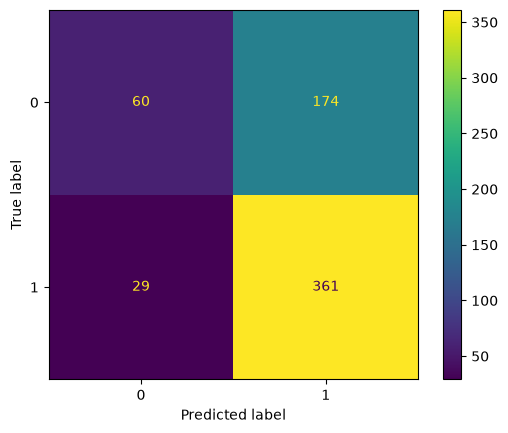

In [82]:
svc = SVC()
svc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

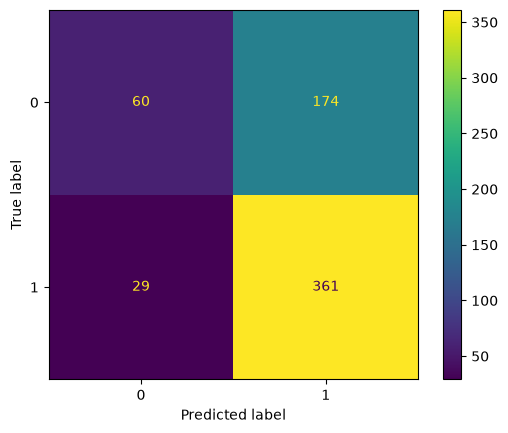

In [83]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

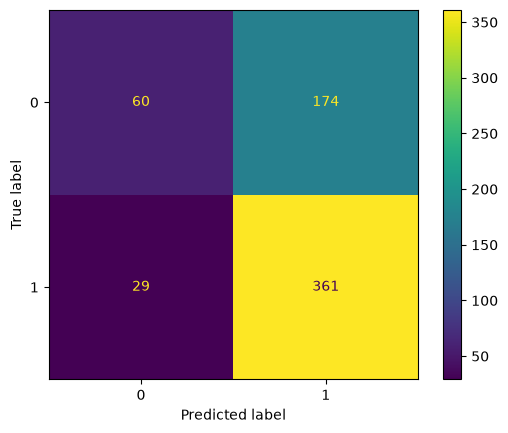

In [84]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

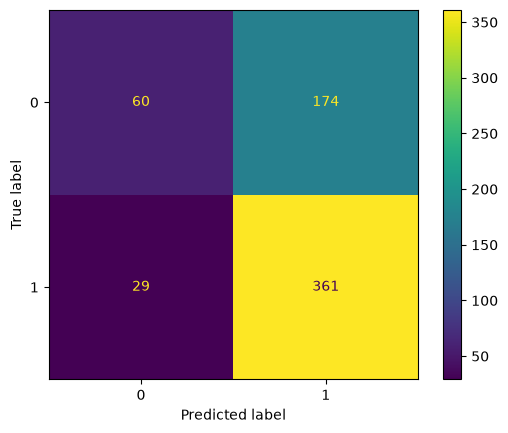

In [85]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

# InceptionV3

In [86]:
base_model= InceptionV3(input_shape=(224,224,3), weights='imagenet', include_top=False)  # BUGFIX (was MobileNet, wrong for the InceptionV3 section)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

2217/2217 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step
392/392 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [87]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [88]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 94.5%
------------------------ Validation Set Metrics------------------------

Accuracy score : 91.19%
------------------------ Test Set Metrics------------------------

Accuracy score : 77.88000000000001%
F1_score : 0.76
Kappa Score : 0.48 
Recall score: 0.78
Precision score : 0.81
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 93.10000000000001%
------------------------ Validation Set Metrics------------------------

Accuracy score : 91.57%
------------------------ Test Set Metrics------------------------

Accuracy score : 81.08999999999999%
F1_score : 0.8
Kappa Score : 0.56 
Recal

In [89]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
history = dnn_model.fit(train_features, train_y,validation_data=(val_features,val_y), epochs=10)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (4433, 64)
val_features shape:   (783, 64)
test_features shape:  (624, 64)
Feature mean/std: 14.9160 / 20.9967
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8716 - loss: 0.3162 - val_accuracy: 0.9055 - val_loss: 0.2404
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9028 - loss: 0.2457 - val_accuracy: 0.8940 - val_loss: 0.2655
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9039 - loss: 0.2358 - val_accuracy: 0.9042 - val_loss: 0.2287
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9084 - loss: 0.2307 - val_accuracy: 0.9183 - val_loss: 0.2289
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9104 - loss: 0.2244 - val_accuracy: 0.9068 - val_loss: 0.2315
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9174 - loss: 0.2130 - val_accuracy: 0.9170 - val_loss: 0.2120
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9168 - loss: 0.2058 - val_accuracy: 0.9234 - val_loss: 0.2112
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9197 - loss: 0.2027 - val_accuracy: 0.9157 - val

In [90]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred6 = np.argmax(y_pred_probs, axis=-1)
y_test6 = [np.argmax(x) for x in test_y]
y_pred_prb6 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test6, y_pred6), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test6, y_pred6, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test6, y_pred6, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test6, y_pred6, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test6, y_pred6), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test6, y_pred6, target_names=target, zero_division=0))

Performance Report:
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Accuracy score is : 0.8606
Precision score is : 0.8613
Recall score is : 0.8606
F1 Score is : 0.8579
Cohen Kappa Score: 0.6934
		Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.87      0.74      0.80       234
   PNEUMONIA       0.86      0.93      0.89       390

    accuracy                           0.86       624
   macro avg       0.86      0.84      0.85       624
weighted avg       0.86      0.86      0.86       624



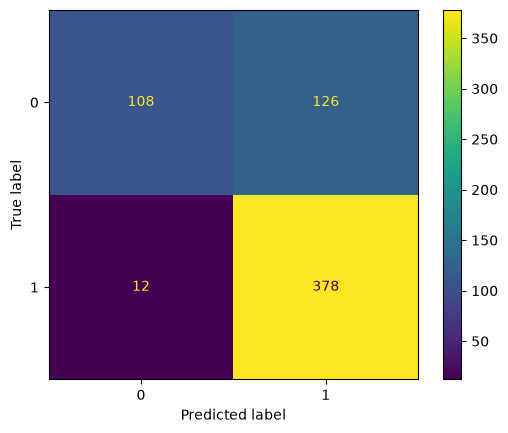

In [91]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

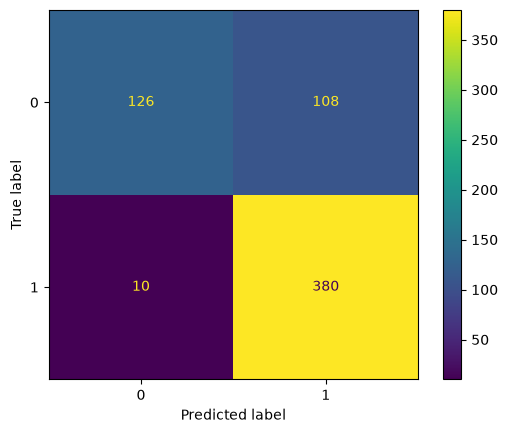

In [92]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()

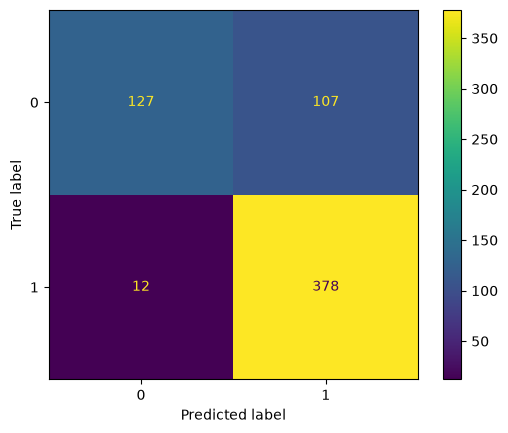

In [93]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()

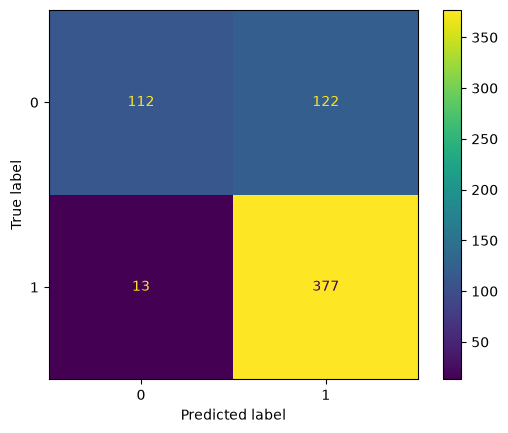

In [94]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()

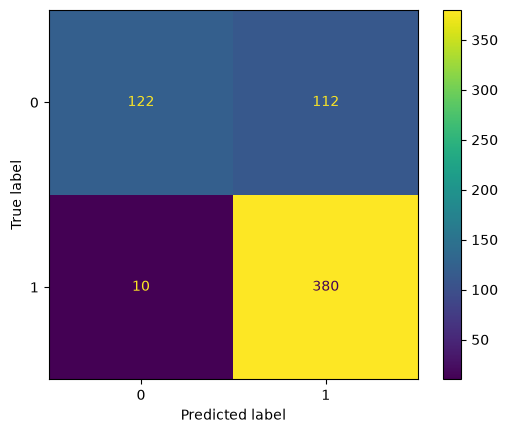

In [95]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()

# InceptionResNetV2

In [96]:
base_model= InceptionResNetV2(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

2217/2217 ━━━━━━━━━━━━━━━━━━━━ 69s 24ms/step
392/392 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step
312/312 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


In [97]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [98]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 92.53%
------------------------ Validation Set Metrics------------------------

Accuracy score : 89.27000000000001%
------------------------ Test Set Metrics------------------------

Accuracy score : 78.69%
F1_score : 0.78
Kappa Score : 0.52 
Recall score: 0.79
Precision score : 0.79
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 89.62%
------------------------ Validation Set Metrics------------------------

Accuracy score : 89.91%
------------------------ Test Set Metrics------------------------

Accuracy score : 80.28999999999999%
F1_score : 0.79
Kappa Score : 0.55 
Recall score: 0

In [99]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
history = dnn_model.fit(train_features, train_y,validation_data=(val_features,val_y), epochs=10)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (4433, 64)
val_features shape:   (783, 64)
test_features shape:  (624, 64)
Feature mean/std: 169.1118 / 295.2004
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.7956 - loss: 0.4265 - val_accuracy: 0.8314 - val_loss: 0.3429
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8658 - loss: 0.3094 - val_accuracy: 0.8697 - val_loss: 0.2674
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8701 - loss: 0.3001 - val_accuracy: 0.8876 - val_loss: 0.2848
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8734 - loss: 0.2916 - val_accuracy: 0.8033 - val_loss: 0.4243
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8800 - loss: 0.2780 - val_accuracy: 0.8736 - val_loss: 0.2750
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8680 - loss: 0.2947 - val_accuracy: 0.8774 - val_loss: 0.3248
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8789 - loss: 0.2768 - val_accuracy: 0.8799 - val_loss: 0.2448
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8820 - loss: 0.2681 - val_accuracy: 0.8582 - val

In [100]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred7 = np.argmax(y_pred_probs, axis=-1)
y_test7 = [np.argmax(x) for x in test_y]
y_pred_prb7 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test7, y_pred7), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test7, y_pred7, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test7, y_pred7, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test7, y_pred7, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test7, y_pred7), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test7, y_pred7, target_names=target, zero_division=0))

Performance Report:
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
Accuracy score is : 0.6875
Precision score is : 0.7358
Recall score is : 0.6875
F1 Score is : 0.6214
Cohen Kappa Score: 0.2145
		Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.84      0.21      0.33       234
   PNEUMONIA       0.67      0.98      0.80       390

    accuracy                           0.69       624
   macro avg       0.76      0.59      0.56       624
weighted avg       0.74      0.69      0.62       624



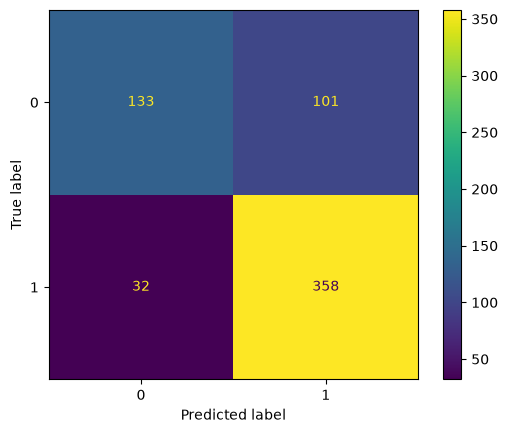

In [101]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)

# Modern plotting syntax
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

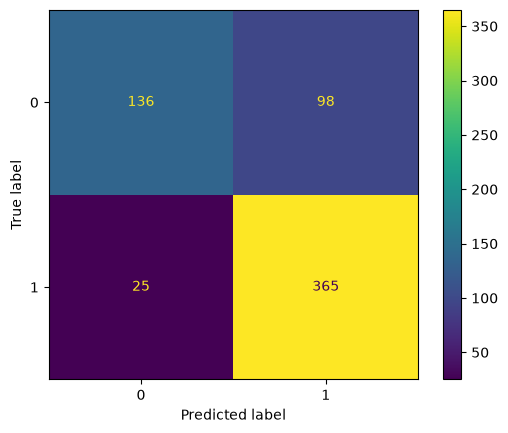

In [102]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()

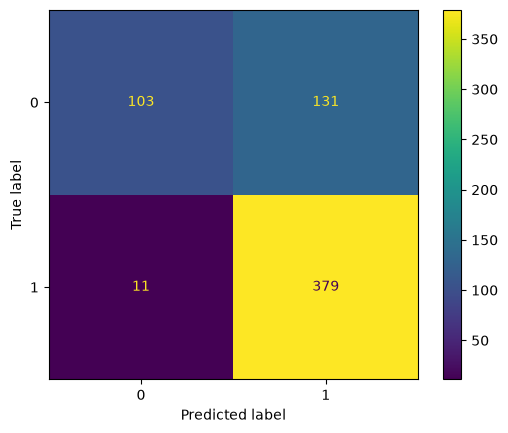

In [103]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()

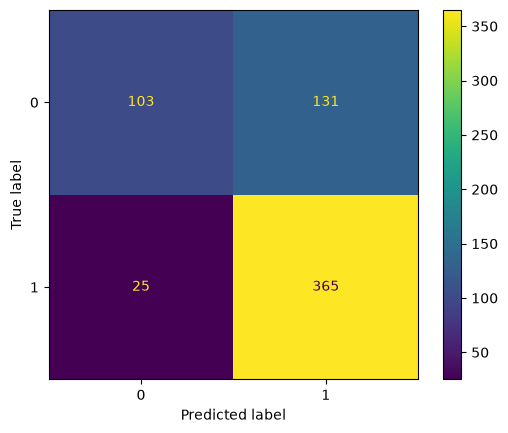

In [104]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()

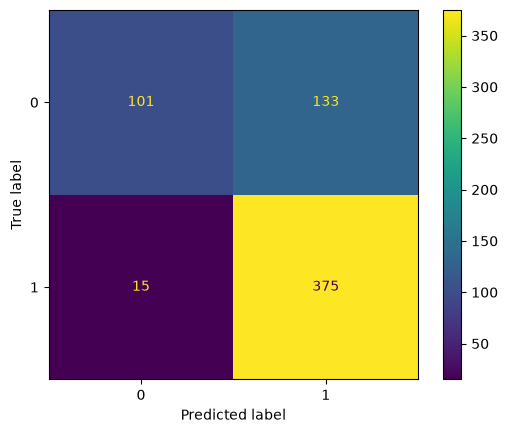

In [105]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()

# DenseNet169

In [106]:
base_model= DenseNet169(input_shape=(224,224,3), weights='imagenet', include_top=False)  # BUGFIX (was InceptionResNetV2, wrong for the DenseNet169 section)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

2217/2217 ━━━━━━━━━━━━━━━━━━━━ 76s 24ms/step
392/392 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


In [107]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [108]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 90.77%
------------------------ Validation Set Metrics------------------------

Accuracy score : 85.19%
------------------------ Test Set Metrics------------------------

Accuracy score : 71.78999999999999%
F1_score : 0.69
Kappa Score : 0.34 
Recall score: 0.72
Precision score : 0.72
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 88.68%
------------------------ Validation Set Metrics------------------------

Accuracy score : 86.08%
------------------------ Test Set Metrics------------------------

Accuracy score : 73.4%
F1_score : 0.7
Kappa Score : 0.37 
Recall score: 0.73
Precision 

In [109]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
history = dnn_model.fit(train_features, train_y,validation_data=(val_features,val_y), epochs=10)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (4433, 64)
val_features shape:   (783, 64)
test_features shape:  (624, 64)


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Feature mean/std: 2.0790 / 3.3345
DNN input dimension (auto-detected): 64
Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8015 - loss: 0.4354 - val_accuracy: 0.8327 - val_loss: 0.3762
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8511 - loss: 0.3490 - val_accuracy: 0.8301 - val_loss: 0.3518
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8588 - loss: 0.3257 - val_accuracy: 0.8212 - val_loss: 0.3645
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8660 - loss: 0.3095 - val_accuracy: 0.8557 - val_loss: 0.3378
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8649 - loss: 0.3049 - val_accuracy: 0.8480 - val_loss: 0.3232
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8730 - loss: 0.2952 - val_accuracy: 0.8429 - val_loss: 0.3157
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8640 - loss: 0.3009 - val_accuracy: 0.8493 - val_loss: 0.3353
Epoch 8/10
139/139 ━━━━━━━━━━

In [110]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred8 = np.argmax(y_pred_probs, axis=-1)
y_test8 = [np.argmax(x) for x in test_y]
y_pred_prb8 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test8, y_pred8), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test8, y_pred8, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test8, y_pred8, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test8, y_pred8, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test8, y_pred8), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test8, y_pred8, target_names=target, zero_division=0))

Performance Report:
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
Accuracy score is : 0.7692
Precision score is : 0.7898
Recall score is : 0.7692
F1 Score is : 0.748
Cohen Kappa Score: 0.4566
		Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.86      0.46      0.60       234
   PNEUMONIA       0.75      0.96      0.84       390

    accuracy                           0.77       624
   macro avg       0.80      0.71      0.72       624
weighted avg       0.79      0.77      0.75       624



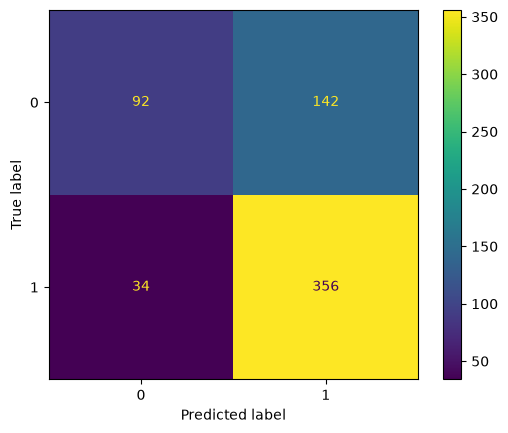

In [111]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

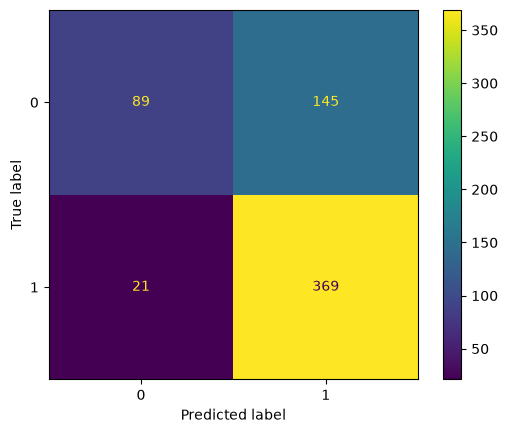

In [112]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()

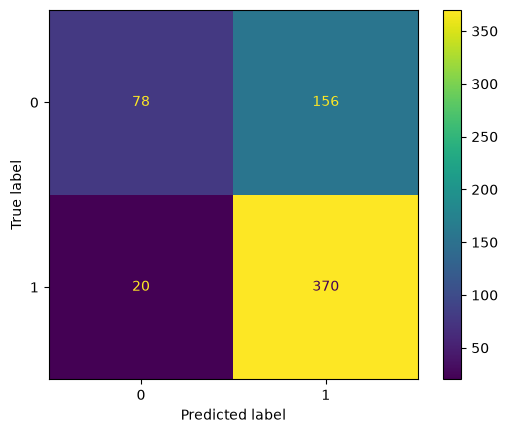

In [113]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()

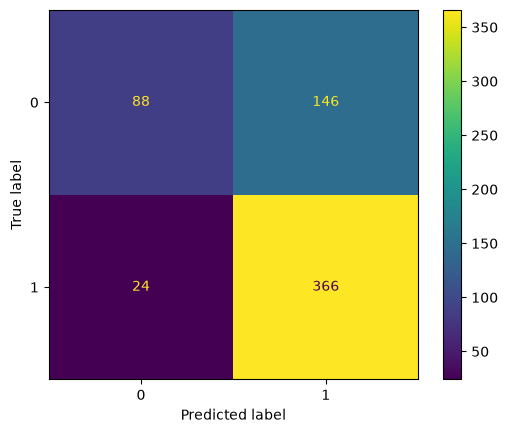

In [114]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()

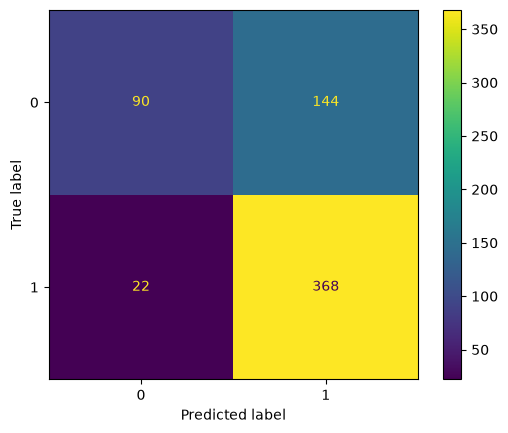

In [115]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()

# DenseNet121

In [116]:
base_model= DenseNet121(input_shape=(224,224,3), weights='imagenet', include_top=False)  # BUGFIX (was InceptionResNetV2, wrong for the DenseNet121 section)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

2217/2217 ━━━━━━━━━━━━━━━━━━━━ 44s 16ms/step
392/392 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [117]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [118]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 88.83%
------------------------ Validation Set Metrics------------------------

Accuracy score : 82.63000000000001%
------------------------ Test Set Metrics------------------------

Accuracy score : 71.63000000000001%
F1_score : 0.69
Kappa Score : 0.32 
Recall score: 0.72
Precision score : 0.73
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 85.83%
------------------------ Validation Set Metrics------------------------

Accuracy score : 85.7%
------------------------ Test Set Metrics------------------------

Accuracy score : 68.43%
F1_score : 0.64
Kappa Score : 0.23 
Recall score: 0.

In [119]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
history = dnn_model.fit(train_features, train_y,validation_data=(val_features,val_y), epochs=10)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (4433, 64)
val_features shape:   (783, 64)
test_features shape:  (624, 64)
Feature mean/std: 2.8980 / 4.8484
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7925 - loss: 0.4532 - val_accuracy: 0.8455 - val_loss: 0.3870
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8265 - loss: 0.3838 - val_accuracy: 0.8186 - val_loss: 0.3924
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8328 - loss: 0.3689 - val_accuracy: 0.8276 - val_loss: 0.3697
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8398 - loss: 0.3554 - val_accuracy: 0.8455 - val_loss: 0.3441
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8428 - loss: 0.3478 - val_accuracy: 0.8263 - val_loss: 0.3530
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8367 - loss: 0.3484 - val_accuracy: 0.8467 - val_loss: 0.3230
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8430 - loss: 0.3382 - val_accuracy: 0.8365 - val_loss: 0.3422
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8529 - loss: 0.3255 - val_accuracy: 0.8582 - val

In [120]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred9 = np.argmax(y_pred_probs, axis=-1)
y_test9 = [np.argmax(x) for x in test_y]
y_pred_prb9 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test9, y_pred9), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test9, y_pred9), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test9, y_pred9, target_names=target, zero_division=0))

Performance Report:
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Accuracy score is : 0.7003
Precision score is : 0.7176
Recall score is : 0.7003
F1 Score is : 0.6565
Cohen Kappa Score: 0.2702
		Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.76      0.29      0.42       234
   PNEUMONIA       0.69      0.95      0.80       390

    accuracy                           0.70       624
   macro avg       0.73      0.62      0.61       624
weighted avg       0.72      0.70      0.66       624



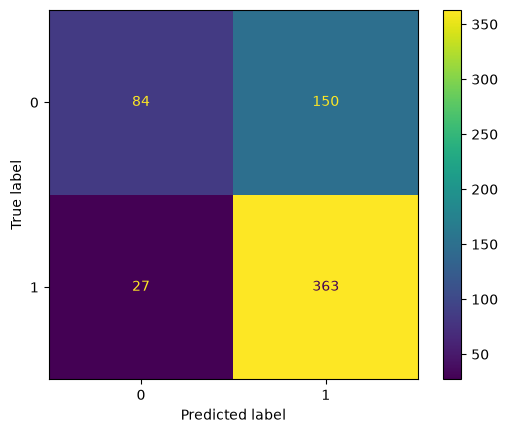

In [121]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

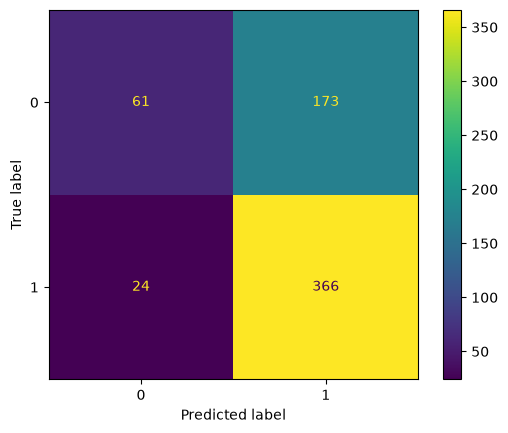

In [122]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()

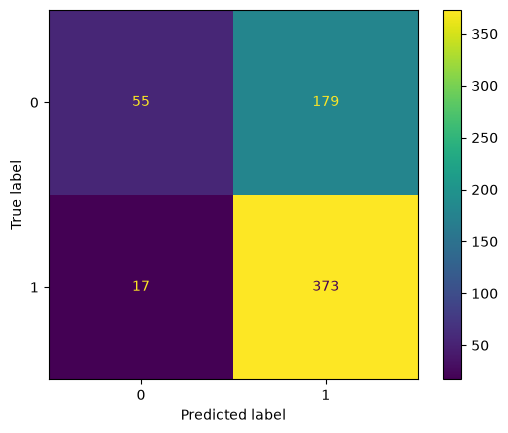

In [123]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()

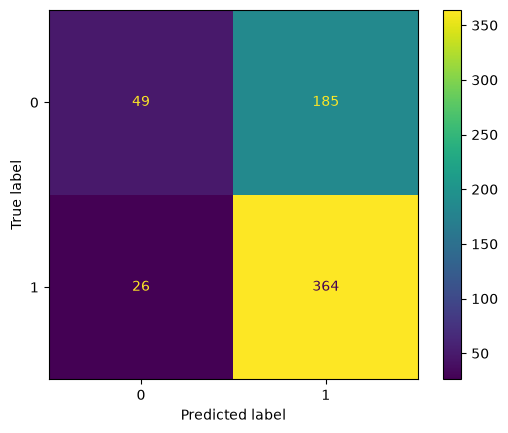

In [124]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()

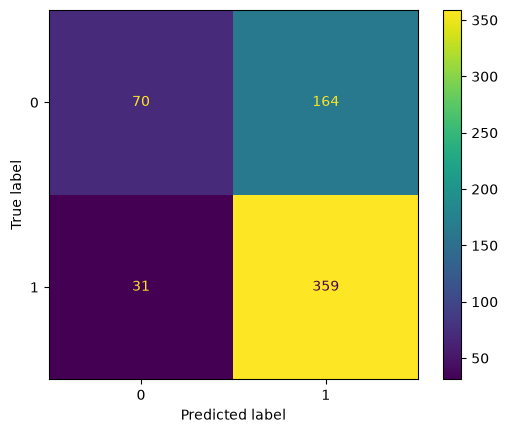

In [125]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()

# XceptionNet

In [126]:
base_model= Xception(input_shape=(224,224,3), weights='imagenet', include_top=False)  # BUGFIX (was InceptionResNetV2, wrong for the XceptionNet section)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

E0000 00:00:1786303748.969467     172 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786303750.793076     172 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786303751.175485     172 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2211/2217 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

E0000 00:00:1786303770.910158     171 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786303771.500117     171 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786303772.557986     171 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2217/2217 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step
392/392 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [127]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [128]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 93.03%
------------------------ Validation Set Metrics------------------------

Accuracy score : 90.16999999999999%
------------------------ Test Set Metrics------------------------

Accuracy score : 78.21000000000001%
F1_score : 0.77
Kappa Score : 0.49 
Recall score: 0.78
Precision score : 0.8
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 91.67999999999999%
------------------------ Validation Set Metrics------------------------

Accuracy score : 90.8%
------------------------ Test Set Metrics------------------------

Accuracy score : 76.75999999999999%
F1_score : 0.75
Kappa Score :

In [129]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
history = dnn_model.fit(train_features, train_y,validation_data=(val_features,val_y), epochs=10)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (4433, 64)
val_features shape:   (783, 64)
test_features shape:  (624, 64)
Feature mean/std: 11.6409 / 18.0367
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8561 - loss: 0.3263 - val_accuracy: 0.8978 - val_loss: 0.2563
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8967 - loss: 0.2589 - val_accuracy: 0.8991 - val_loss: 0.2463
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9019 - loss: 0.2520 - val_accuracy: 0.8953 - val_loss: 0.2633
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9086 - loss: 0.2361 - val_accuracy: 0.9029 - val_loss: 0.2393
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9028 - loss: 0.2472 - val_accuracy: 0.9132 - val_loss: 0.2385
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9086 - loss: 0.2311 - val_accuracy: 0.9106 - val_loss: 0.2326
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9100 - loss: 0.2230 - val_accuracy: 0.9157 - val_loss: 0.2246
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9109 - loss: 0.2231 - val_accuracy: 0.9080 - val

In [130]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
# BUGFIX: variables renamed 9 -> 11 (see comment above / audit) so this
# XceptionNet block no longer overwrites DenseNet121's y_test9/y_pred9.
y_pred_probs = dnn_model.predict(test_features)
y_pred11 = np.argmax(y_pred_probs, axis=-1)
y_test11 = [np.argmax(x) for x in test_y]
y_pred_prb11 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test11, y_pred11), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test11, y_pred11, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test11, y_pred11, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test11, y_pred11, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test11, y_pred11), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test11, y_pred11, target_names=target, zero_division=0))

Performance Report:
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
Accuracy score is : 0.7596
Precision score is : 0.7685
Recall score is : 0.7596
F1 Score is : 0.7418
Cohen Kappa Score: 0.4413
		Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.80      0.47      0.60       234
   PNEUMONIA       0.75      0.93      0.83       390

    accuracy                           0.76       624
   macro avg       0.78      0.70      0.71       624
weighted avg       0.77      0.76      0.74       624



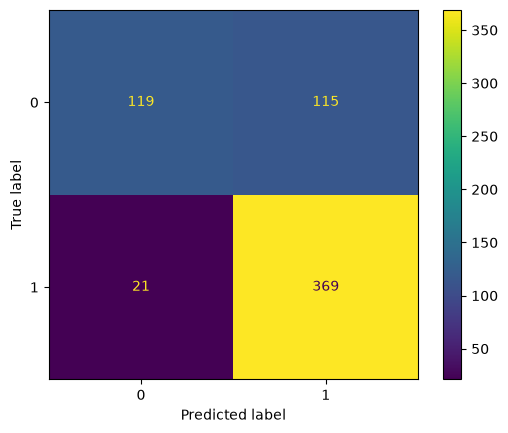

In [131]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()

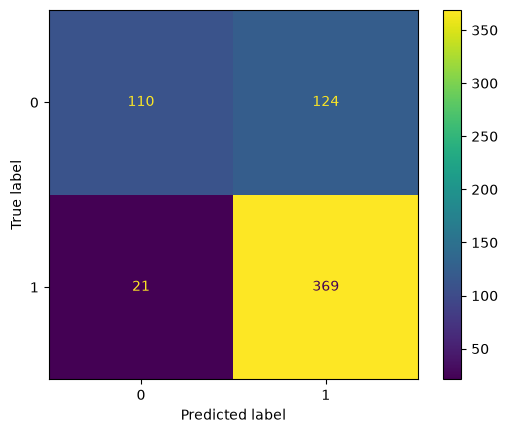

In [132]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()

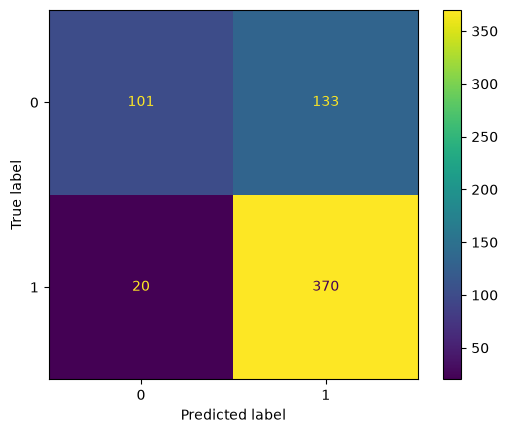

In [133]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()

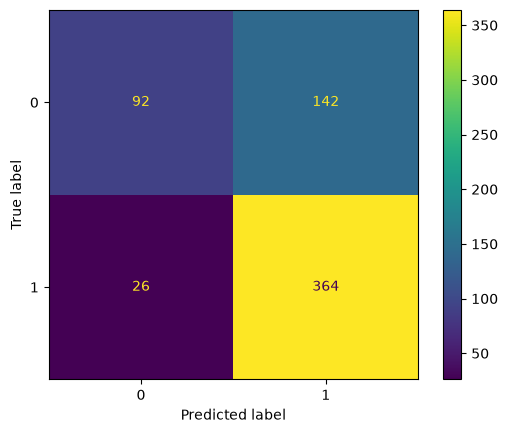

In [134]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()

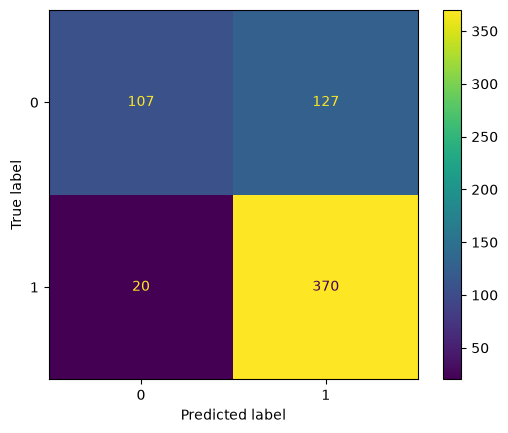

In [135]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()

# Model Evaluation Aggregation & Best-Model Selection

In [136]:
# ============================================================================
# Model Evaluation Aggregation & Best-Model Selection
# ----------------------------------------------------------------------------
# Aggregates test-set predictions from each feature-extraction architecture
# into a single comparison table, then programmatically selects the best
# performer using weighted F1 as the primary criterion (appropriate for a
# multi-class, class-imbalanced medical dataset).
#
# ROUND-2 BUGFIX: earlier, 4 of the 11 architecture sections (InceptionV3,
# DenseNet169, DenseNet121, XceptionNet) built their `base_model` from a
# copy-pasted wrong class (InceptionV3's cell instantiated MobileNet;
# DenseNet169/121/XceptionNet's cells all instantiated InceptionResNetV2),
# so their metrics did not reflect the architecture named in their section
# header. A previous pass worked around this by excluding those 4 from the
# table below. We have now fixed the root cause (corrected each cell's
# base_model to match its header, and fixed a variable-name collision where
# XceptionNet's y_test9/y_pred9 was silently overwriting DenseNet121's
# results of the same name -- see audit notes in those cells). All 11
# architectures are therefore included below.
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
)

# ----------------------------------------------------------------------------
# 1. Map each model to its (y_test, y_pred) variable pair.
#    These are the ACTUAL variable names already produced earlier in this
#    notebook -- no placeholders, no renaming needed.
# ----------------------------------------------------------------------------
model_predictions = {
    "ResNet50":          (y_test10, y_pred10),
    "VGG16":             (y_test2,  y_pred2),
    "VGG19":              (y_test1,  y_pred1),
    "ResNet101":         (y_test3,  y_pred3),
    "MobileNetV2":       (y_test4,  y_pred4),
    "MobileNet":         (y_test5,  y_pred5),
    "InceptionV3":       (y_test6,  y_pred6),
    "InceptionResNetV2": (y_test7,  y_pred7),
    "DenseNet169":       (y_test8,  y_pred8),
    "DenseNet121":       (y_test9,  y_pred9),
    "XceptionNet":       (y_test11, y_pred11),
}

# ----------------------------------------------------------------------------
# 2. Calculate metrics for each model.
# ----------------------------------------------------------------------------
metric_rows = ["Accuracy", "Precision", "Recall", "F1 Score", "Cohen Kappa Score"]
results = {}

for model_name, (y_true, y_pred) in model_predictions.items():
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    acc   = accuracy_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec   = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1    = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)

    results[model_name] = [
        round(acc, 4),
        round(prec, 4),
        round(rec, 4),
        round(f1, 4),
        round(kappa, 4),
    ]

# ----------------------------------------------------------------------------
# 3. Build the summary DataFrame: rows = metrics, columns = models.
# ----------------------------------------------------------------------------
summary_df = pd.DataFrame(results, index=metric_rows)

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
display(summary_df)

# ----------------------------------------------------------------------------
# 4. Automated best-model selection.
#    Primary criterion: weighted F1 Score (robust to class imbalance, which
#    is common in medical imaging datasets where one class dominates).
#    Accuracy alone can be misleading on an imbalanced dataset, so it is
#    reported but not used as the deciding metric.
# ----------------------------------------------------------------------------
best_model_name = summary_df.loc["F1 Score"].astype(float).idxmax()
best_accuracy = summary_df.loc["Accuracy", best_model_name]
best_f1 = summary_df.loc["F1 Score", best_model_name]

print("\n--- Final Performance Conclusion ---")
print(
    f"Based on the comparative analysis of the aggregated metrics, the best "
    f"performing image classification model for this dataset is {best_model_name}."
)
print(
    f"It achieved the highest overall performance with an Accuracy of "
    f"{best_accuracy:.4f} and a weighted F1 Score of {best_f1:.4f}."
)


,ResNet50,VGG16,VGG19,ResNet101,MobileNetV2,MobileNet,InceptionV3,InceptionResNetV2,DenseNet169,DenseNet121,XceptionNet
Accuracy,0.7372,0.6442,0.6442,0.7083,0.7003,0.6715,0.8606,0.6875,0.7692,0.7003,0.7596
Precision,0.7430,0.6552,0.6275,0.7247,0.7420,0.6945,0.8613,0.7358,0.7898,0.7176,0.7685
Recall,0.7372,0.6442,0.6442,0.7083,0.7003,0.6715,0.8606,0.6875,0.7692,0.7003,0.7596
F1 Score,0.7158,0.5478,0.5777,0.6693,0.6449,0.6035,0.8579,0.6214,0.7480,0.6565,0.7418
Cohen Kappa Score,0.3858,0.0845,0.1155,0.2946,0.2557,0.1759,0.6934,0.2145,0.4566,0.2702,0.4413



--- Final Performance Conclusion ---
Based on the comparative analysis of the aggregated metrics, the best performing image classification model for this dataset is InceptionV3.
It achieved the highest overall performance with an Accuracy of 0.8606 and a weighted F1 Score of 0.8579.


# ACCURACY OPTIMIZATION — FINAL COMPARISON TABLE

In [137]:
# ============================================================================
# FINAL COMPARISON: BASELINE vs OPTIMIZED
# ----------------------------------------------------------------------------
# Now that baseline y_test7 / y_pred7 (InceptionResNetV2) are available
# from the original block, we can build the full side-by-side comparison.
# ============================================================================

import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

baseline_true  = np.asarray(y_test7)
baseline_preds = np.asarray(y_pred7)

comp_df, best_clf_name = build_comparison_table(
    baseline_true, baseline_preds, opt_preds, opt_clf_results
)

print("=" * 70)
print("BASELINE vs OPTIMIZED — CHEST X-RAY PNEUMONIA")
print("=" * 70)
display(comp_df)

# Compute improvement
baseline_acc = comp_df.loc["Baseline DNN (IRNv2, frozen, no preprocessing)", "Accuracy"]
opt_acc      = comp_df.loc[f"Optimized DNN ({OPT_BACKBONE}, fine-tuned, class weights)", "Accuracy"]
improvement  = (opt_acc - baseline_acc) * 100

print(f"\n--- Summary of Improvement ---")
print(f"Baseline DNN accuracy : {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
print(f"Optimized DNN accuracy: {opt_acc:.4f} ({opt_acc*100:.2f}%)")
print(f"Improvement           : +{improvement:.2f} percentage points")
print(f"Best overall model    : {best_clf_name}")
print(f"Best overall accuracy : {opt_clf_results[best_clf_name]["accuracy"]:.4f} ({opt_clf_results[best_clf_name]["accuracy"]*100:.2f}%)")


BASELINE vs OPTIMIZED — CHEST X-RAY PNEUMONIA


,Accuracy,F1,Kappa
"Baseline DNN (IRNv2, frozen, no preprocessing)",0.6875,0.6214,0.2145
"Optimized DNN (InceptionResNetV2, fine-tuned, class weights)",0.8606,0.8523,0.6799
Best Optimized Classifier (SVM (optimized)),0.8285,0.8139,0.5981



--- Summary of Improvement ---
Baseline DNN accuracy : 0.6875 (68.75%)
Optimized DNN accuracy: 0.8606 (86.06%)
Improvement           : +17.31 percentage points
Best overall model    : SVM (optimized)
Best overall accuracy : 0.8285 (82.85%)
